In [ ]:
!pip install pdfplumber pandas numpy

In [1]:
!pip install pypdf

Defaulting to user installation because normal site-packages is not writeable
  Using cached pypdf-6.18.1-py3-none-any.whl (394 kB)


In [1]:
import pandas as pd

from pypdf import PdfReader
import numpy as np
import re
from pathlib import Path
import pdfplumber

In [ ]:
data_folder = Path("../data/raw")

csv_files = list(data_folder.glob("*.csv"))
pdf_files = list(data_folder.glob("*.pdf"))

print("CSV files:")
for file in csv_files:
    print(file)

print("\nPDF files:")
for file in pdf_files:
    print(file)

In [ ]:
csv_data = {}

for file in csv_files:
    df = pd.read_csv(file)
    csv_data[file.name] = df

print(csv_data.keys())

In [ ]:
pdf_data = {}

for file in pdf_files:
    reader = PdfReader(file)

    text = ""

    for page in reader.pages:
        text += page.extract_text() or ""

    pdf_data[file.name] = text

print(pdf_data.keys())

## INSPECTING "2026 BUDGET" AND "2025 OBB FINAL"

In [ ]:
data_folder = Path("../data/raw") 
output_folder = Path("../data/processed") 
output_folder.mkdir(parents=True, exist_ok=True)

In [ ]:
for pdf_file in pdf_files:

    if "2025-OBB" in pdf_file.name or "2026-Budget" in pdf_file.name:

        print(f"\nProcessing: {pdf_file.name}")

        extracted_tables = []

        with pdfplumber.open(pdf_file) as pdf:

            for page_num, page in enumerate(pdf.pages, start=1):

                tables = page.extract_tables()

                for table in tables:

                    if table:

                        df = pd.DataFrame(table)

                        # Remove empty rows and columns
                        df = df.fillna("")
                        df = df.map(
                            lambda cell: cell.strip()
                            if isinstance(cell, str)
                            else cell
                        )

                        df = df.loc[~(df == "").all(axis=1)]
                        df = df.loc[:, ~(df == "").all(axis=0)]

                        if not df.empty:
                            df["source_page"] = page_num
                            extracted_tables.append(df)

        if extracted_tables:

            final_df = pd.concat(
                extracted_tables,
                ignore_index=True
            )

            clean_name = (
                pdf_file.stem
                .lower()
                .replace("-", "_")
                .replace(".", "_")
            )

            output_file = (
                output_folder /
                f"db-unza26-csc4792-{clean_name}.csv"
            )

            final_df.to_csv(
                output_file,
                sep="|",
                index=False
            )

            print(f"Saved: {output_file}")
            print(f"Rows: {len(final_df)}")
            print(f"Columns: {len(final_df.columns)}")

        else:
            print("No tables found.")

In [ ]:
processed_files = list(output_folder.glob("*.csv"))

print("Processed CSV files:")

for file in processed_files:
    print(file)

In [ ]:
obb_dataset = pd.read_csv(
    "../data/processed/db-unza26-csc4792-petauke_town_council_2025_obb_final_05_12_2024_signed.csv",
    sep="|"
)

obb_dataset.head()

In [ ]:
budget_dataset = pd.read_csv(
    "../data/processed/db-unza26-csc4792-petauke_town_council_2026_budget_2026.csv",
    sep="|"
)

budget_dataset


### PDF Table Profiler

Surveys all PDFs in `data/raw` to identify what's worth extracting.

In [ ]:
for f in sorted(data_folder.glob("*.pdf")):
    print("\n" + "=" * 100)
    print(f"FILE: {f.name}")
    print("=" * 100)

    with pdfplumber.open(f) as pdf:
        print(f"Total pages: {len(pdf.pages)}")

        for pnum, page in enumerate(pdf.pages, start=1):
            tables = page.extract_tables()

            if not tables:
                continue

            for tidx, table in enumerate(tables):
                if not table or len(table) < 2:
                    continue

                n_cols = max(len(r) for r in table)
                n_rows = len(table)

                print(f"\n  ▸ Page {pnum} | Table {tidx} | {n_rows} rows × {n_cols} cols")
                print("    ── First 3 rows ──")
                for row in table[:3]:
                    cells = [
                        (str(c)[:30] + "…") if c and len(str(c)) > 30 else str(c)
                        for c in row
                    ]
                    print("    |", " | ".join(cells))

### 2025 OBB — Revenue Budget Extraction

Extracts the revenue budget table from the raw 2025 OBB extraction
(`db-unza26-csc4792-petauke_town_council_2025_obb_final_05_12_2024_signed.csv`).

In [ ]:
raw_path = Path("../data/processed/db-unza26-csc4792-petauke_town_council_2025_obb_final_05_12_2024_signed.csv")

df = pd.read_csv(raw_path, sep="|", dtype=str, header=None)

header_mask = df[0].astype(str).str.strip().str.upper() == "CODE"
header_positions = df.index[header_mask].tolist()

first_header = header_positions[0]

grand_total_mask = df[0].astype(str).str.contains("Grand Total", case=False, na=False)
grand_positions = df.index[grand_total_mask].tolist()
last_data_row = grand_positions[0] if grand_positions else len(df) - 1

df = df.iloc[first_header + 1 : last_data_row + 1].reset_index(drop=True)

df.columns = [
    "code",
    "description",
    "approved_budget_2025",
    "_drop1",
    "revised_budget_2026",
    "budget_estimate_2027",
    "source_page",
    "_drop2",
    "_drop3",
]

df = df.drop(columns=["_drop1", "_drop2", "_drop3"])

df = df[~df["code"].astype(str).str.strip().str.upper().eq("CODE")]
df = df.dropna(how="all")

df["code"] = df["code"].astype(str).str.strip()
df["description"] = df["description"].astype(str).str.strip()

df["is_category"] = df["code"].str.match(r"^\d{2}$", na=False)
df["is_subitem_total"] = df["description"].str.contains("SubItem Total", case=False, na=False)
df["is_grand_total"] = df["code"].str.contains("Grand Total", case=False, na=False)

df["category"] = df["description"].where(df["is_category"]).ffill()

grand = df[df["is_grand_total"]].iloc[0] if df["is_grand_total"].any() else None

df_items = df[
    ~df["is_category"]
    & ~df["is_subitem_total"]
    & ~df["is_grand_total"]
    & df["code"].str.match(r"^\d{3}$", na=False)
].copy()

# Convert budget columns to numeric
def to_num(s):
    if s is None or (isinstance(s, float) and np.isnan(s)):
        return np.nan
    s = str(s).strip().replace(",", "")
    s = re.sub(r"^\((.+)\)$", r"-\1", s)   # (0) -> -0
    if s in ("", "-", "nan", "None"):
        return np.nan
    try:
        return float(s)
    except ValueError:
        return np.nan

for col in ["approved_budget_2025", "revised_budget_2026", "budget_estimate_2027"]:
    df_items[col] = df_items[col].apply(to_num)

# ---- NEW: cast to Int64 so CSV prints without ".0" ----
for col in ["approved_budget_2025", "revised_budget_2026", "budget_estimate_2027"]:
    df_items[col] = df_items[col].astype("Int64")

# Reorder, add serial number, reset index
df_items = df_items[
    ["category", "code", "description",
     "approved_budget_2025", "revised_budget_2026", "budget_estimate_2027"]
].reset_index(drop=True)

df_items.insert(0, "sn", range(1, len(df_items) + 1))

df_items = df_items.rename(columns={"description": "revenue_item"})

# ---------------------------------------------------------------
# Sanity checks
# ---------------------------------------------------------------
print("Rows:", len(df_items))
print("Columns:", df_items.columns.tolist())
print()
print(df_items.head(15).to_string())
print()
print("Sum check (should match Grand Total per column):")
print(f"  approved_budget_2025 : {df_items['approved_budget_2025'].sum():>15,.0f}")
print(f"  revised_budget_2026  : {df_items['revised_budget_2026'].sum():>15,.0f}")
print(f"  budget_estimate_2027 : {df_items['budget_estimate_2027'].sum():>15,.0f}")

out = Path("../data/processed/db-unza26-csc4792-petauke_town_council_budget_2025_obb.csv")
df_items.to_csv(out, sep="|", index=False)
print(f"\nSaved: {out}")

Rows: 57
Columns: ['sn', 'category', 'code', 'revenue_item', 'approved_budget_2025', 'revised_budget_2026', 'budget_estimate_2027']

    sn           category code                                       revenue_item  approved_budget_2025  revised_budget_2026  budget_estimate_2027
0    1  Local taxes/rates  001                                        Residential               2000000              2000000               2000000
1    2  Local taxes/rates  002                                         Commercial               2000000              2000000               2000000
2    3  Local taxes/rates  001                                      Personal levy                 73500                80850                 97020
3    4   Fees and Charges  001                                       Consent fees                 16000                17600                 21120
4    5   Fees and Charges  002                                        Survey fees                 41000                45100        

# PETAUKE TOWN COUNCIL — 2025 OBB EXTRACTION & CLEANING

### Extracts the remaining non-revenue tables from the raw 2025 OBB extraction.

### Outputs:
- `db-unza26-csc4792-petauke_town_council_expenditure_economic_classification.csv`
- `db-unza26-csc4792-petauke_town_council_expenditure_programme.csv`
- `db-unza26-csc4792-petauke_town_council_performance_indicators.csv`
- `db-unza26-csc4792-petauke_town_council_cdf_and_lgef.csv`

In [ ]:


# Paths
raw_path = Path("../data/processed/db-unza26-csc4792-petauke_town_council_2025_obb_final_05_12_2024_signed.csv")
out_dir  = Path("../data/cleaned")
out_dir.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(raw_path, sep="|", dtype=str, header=None)


# Helpers
def to_num(s):
    if s is None or (isinstance(s, float) and np.isnan(s)):
        return np.nan
    s = str(s).strip().replace(",", "")
    s = re.sub(r"^\((.+)\)$", r"-\1", s)
    if s in ("", "-", "nan", "None"):
        return np.nan
    try:
        return float(s)
    except ValueError:
        return np.nan


def to_text(s):
    if s is None or (isinstance(s, float) and np.isnan(s)):
        return np.nan
    s = str(s).replace("\r", " ").replace("(cid:9)", " ")
    s = re.sub(r"\s+", " ", s).strip()
    return s if s else np.nan


def split_lines(cell):
    return [x.strip() for x in str(cell).split("\n") if x.strip()]


def add_sn(frame, loc=0):
    frame = frame.drop(columns=["sn"], errors="ignore").reset_index(drop=True)
    frame.insert(loc, "sn", range(1, len(frame) + 1))
    return frame


def int64_cols(frame, cols):
    for c in cols:
        if c in frame.columns:
            frame[c] = frame[c].astype("Int64")
    return frame


# 1. Expenditure by economic classification
econ_start = df.index[
    df[0].astype(str).str.strip().str.lower().isin(["no", "no."])
    & df[1].astype(str).str.contains("ECONOMIC", case=False, na=False)
].tolist()

econ_rows = []
if econ_start:
    start = econ_start[0]
    for i in range(start + 1, len(df)):
        code_cell = str(df.iloc[i, 0])
        if "head total" in code_cell.lower():
            break
        if not re.match(r"^[\d\s]+$", code_cell.strip()):
            if econ_rows:
                break
            continue

        codes = re.findall(r"\d+", code_cell)
        names = split_lines(df.iloc[i, 1])
        a2024 = split_lines(df.iloc[i, 3])

        for j, name in enumerate(names):
            econ_rows.append({
                "code":           codes[j] if j < len(codes) else None,
                "classification": name,
                "approved_2024":  to_num(a2024[j]) if j < len(a2024) else np.nan,
            })

df_econ = pd.DataFrame(econ_rows)
if not df_econ.empty:
    df_econ = df_econ.dropna(subset=["classification"]).reset_index(drop=True)
    df_econ = add_sn(df_econ)


# 2. Expenditure by programme
prog_start = df.index[
    df[0].astype(str).str.strip().str.lower().isin(["code"])
    & df[1].astype(str).str.contains("Programme", case=False, na=False)
].tolist()

prog_rows = []
if prog_start:
    start = prog_start[0]
    for i in range(start + 1, len(df)):
        code_cell = str(df.iloc[i, 0])
        if "head total" in code_cell.lower():
            if prog_rows:
                break
            continue
        if not re.match(r"^[\d\s]+$", code_cell.strip()):
            if prog_rows:
                break
            continue

        codes = re.findall(r"\d+", code_cell)
        names = split_lines(df.iloc[i, 1])
        a2024 = split_lines(df.iloc[i, 3])

        for j, name in enumerate(names):
            prog_rows.append({
                "programme_code": codes[j] if j < len(codes) else None,
                "programme_name": name,
                "approved_2024":  to_num(a2024[j]) if j < len(a2024) else np.nan,
            })

df_prog = pd.DataFrame(prog_rows)
if not df_prog.empty:
    df_prog = df_prog.dropna(subset=["programme_name"]).reset_index(drop=True)
    df_prog = add_sn(df_prog)


# 3. Performance indicators
ind_starts = df.index[
    df[0].astype(str).str.contains("Key Output", case=False, na=False)
].tolist()

ind_rows = []
for start in ind_starts:
    for i in range(start + 1, len(df)):
        indicator_cell = str(df.iloc[i, 0])

        if any(k in indicator_cell for k in [
            "ECONOMIC CLASSIFICATION", "PROGRAMME/SUB-PROGRAMME",
            "Grand Total", "Head Total", "PROGRAMME/SUBPROGRAMME",
        ]):
            break
        if not indicator_cell.strip() or indicator_cell.lower() == "nan":
            continue
        if "target" in indicator_cell.lower() and "actual" not in indicator_cell.lower():
            continue

        label_lines = split_lines(indicator_cell)
        group_name = label_lines[0] if label_lines else None

        target_2024 = split_lines(df.iloc[i, 4])
        target_2025 = split_lines(df.iloc[i, 6])

        n = max(
            len(label_lines),
            len(target_2024), len(target_2025),
            1,
        )

        for k in range(n):
            ind_rows.append({
                "indicator_group": group_name,
                "indicator":       label_lines[k] if k < len(label_lines) else None,
                "target_2024":     to_num(target_2024[k]) if k < len(target_2024) else np.nan,
                "target_2025":     to_num(target_2025[k]) if k < len(target_2025) else np.nan,
            })

df_ind = pd.DataFrame(ind_rows)
if not df_ind.empty:
    df_ind = df_ind.dropna(subset=["indicator"], how="all")
    value_cols = ["target_2024", "target_2025",]
    df_ind = df_ind[df_ind[value_cols].notna().any(axis=1)].reset_index(drop=True)
    df_ind = add_sn(df_ind)


# 4. CDF + LGEF (filtered from revenue table)
rev = pd.read_csv(
    out_dir / "db-unza26-csc4792-petauke_town_council_budget_2025_obb.csv",
    sep="|",
)

cdf_lgef = (
    rev[rev["category"].isin(["Local Development Fund", "National Support (Grants)"])]
    .copy()
    .drop(columns=["sn"], errors="ignore")
    .reset_index(drop=True)
)
cdf_lgef = add_sn(cdf_lgef)


# Cast numeric columns to Int64 (removes .0)
df_econ  = int64_cols(df_econ,  ["approved_2024"])
df_prog  = int64_cols(df_prog,  ["approved_2024"])
df_ind   = int64_cols(df_ind,   ["target_2024",
                                 "target_2025",])
cdf_lgef = int64_cols(cdf_lgef, ["approved_budget_2025", "revised_budget_2026",
                                 "budget_estimate_2027"])


# Save all
files = {
    "expenditure_economic_classification": df_econ,
    "expenditure_programme":               df_prog,
    "performance_indicators":              df_ind,
    "cdf_and_lgef":                        cdf_lgef,
}

print("\n=== SAVING FILES ===")
for name, frame in files.items():
    path = out_dir / f"db-unza26-csc4792-petauke_town_council_{name}.csv"
    if not frame.empty:
        frame.to_csv(path, sep="|", index=False)
        print(f"✓ {path.name}  ({len(frame)} rows, {len(frame.columns)} cols)")
    else:
        print(f"✗ {path.name}  (empty — check extraction logic)")


# Preview
print("\n=== Economic Classification ===")
print(df_econ.to_string() if not df_econ.empty else "(empty)")

print("\n=== Programme ===")
print(df_prog.to_string() if not df_prog.empty else "(empty)")

print("\n=== Performance Indicators (first 15) ===")
print(df_ind.head(15).to_string() if not df_ind.empty else "(empty)")

print("\n=== CDF + LGEF ===")
print(cdf_lgef.to_string() if not cdf_lgef.empty else "(empty)")


=== SAVING FILES ===
✓ db-unza26-csc4792-petauke_town_council_expenditure_economic_classification.csv  (7 rows, 4 cols)
✓ db-unza26-csc4792-petauke_town_council_expenditure_programme.csv  (15 rows, 4 cols)
✓ db-unza26-csc4792-petauke_town_council_performance_indicators.csv  (126 rows, 5 cols)
✓ db-unza26-csc4792-petauke_town_council_cdf_and_lgef.csv  (6 rows, 7 cols)

=== Economic Classification ===
   sn code                                 classification  approved_2024
0   1   21                            Personal Emoluments       18634039
1   2   22                             Goods and Services       15841398
2   3   26           Grants and Other Payments(Transfers)           <NA>
3   4   27         Subsidies to Non-Financial Enterprises       16298162
4   5   31                           Non-Financial Assets       43367347
5   6   32                               Financial Assets        6984926
6   7   41  Current Liabilities (Payable within one year)         555500

=== Program

# PETAUKE TOWN COUNCIL — 2026 BUDGET EXTRACTION & CLEANING

### Extracts all tabular sections from the raw 2026 budget file (`db-unza26-csc4792-petauke_town_council_2026_budget_2026.csv`).

### Outputs:
- `db-unza26-csc4792-petauke_town_council_budget_2026_revenue.csv`
- `db-unza26-csc4792-petauke_town_council_budget_2026_expenditure.csv`
- `db-unza26-csc4792-petauke_town_council_budget_2026_performance_indicators.csv`
- `db-unza26-csc4792-petauke_town_council_budget_2026_cdf_and_grants.csv`

In [ ]:
# Paths
raw_path = Path("../data/processed/db-unza26-csc4792-petauke_town_council_2026_budget_2026.csv")
out_dir  = Path("../data/cleaned")
out_dir.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(raw_path, sep="|", dtype=str, header=None)
print(f"Loaded raw file: {df.shape[0]} rows × {df.shape[1]} cols\n")


# Helpers
def to_num(s):
    if s is None or (isinstance(s, float) and np.isnan(s)):
        return np.nan
    s = str(s).strip().replace(",", "")
    s = re.sub(r"^\((.+)\)$", r"-\1", s)
    if s in ("", "-", "nan", "None"):
        return np.nan
    try:
        return float(s)
    except ValueError:
        return np.nan


def to_text(s):
    if s is None or (isinstance(s, float) and np.isnan(s)):
        return np.nan
    s = str(s).replace("\r", " ").replace("(cid:9)", " ")
    s = re.sub(r"\s+", " ", s).strip()
    return s if s else np.nan


def split_lines(cell):
    return [x.strip() for x in str(cell).split("\n") if x.strip()]


def add_sn(frame, loc=0):
    frame = frame.drop(columns=["sn"], errors="ignore").reset_index(drop=True)
    frame.insert(loc, "sn", range(1, len(frame) + 1))
    return frame


def int64_cols(frame, cols):
    for c in cols:
        if c in frame.columns:
            frame[c] = frame[c].astype("Int64")
    return frame


# 1. Revenue budget (2026)
rev_header_positions = df.index[
    df[0].astype(str).str.strip().str.upper().eq("CODE")
    & df[1].astype(str).str.contains("REVENUE DESCRIPTION", case=False, na=False)
].tolist()

rev_rows = []

for start in rev_header_positions:
    header_row = df.iloc[start]

    # Determine which physical column holds each field based on the header text
    col_map = {}
    for c in range(2, header_row.shape[0]):
        cell = str(header_row[c]).upper()
        if "APPROVED" in cell and "2026" in cell:
            col_map["approved"] = c
        elif "REVISED" in cell and "2027" in cell:
            col_map["revised"] = c
        elif "ESTIMATE" in cell and "2028" in cell:
            col_map["estimate"] = c

    for i in range(start + 1, len(df)):
        code_cell = str(df.iloc[i, 0]).strip()
        if code_cell.upper() == "CODE":
            break
        if code_cell.upper() == "NO" or "Grand Total" in code_cell:
            break

        code = code_cell
        desc = to_text(df.iloc[i, 1])
        if not desc or desc == "SubItem Total":
            continue
        if not re.match(r"^\d{3}$", code):
            continue

        approved = to_num(df.iloc[i, col_map.get("approved", 2)])
        revised  = to_num(df.iloc[i, col_map.get("revised",  4)])
        estimate = to_num(df.iloc[i, col_map.get("estimate", 6)])

        # Detect source_page — small integer 1..99 in any column 2..8
        source_page = None
        for c in range(2, df.shape[1]):
            v = str(df.iloc[i, c]).strip()
            if re.match(r"^\d{1,2}$", v) and 1 <= int(v) <= 99:
                source_page = v
                break

        rev_rows.append({
            "code":                 code,
            "revenue_item":         desc,
            "approved_budget_2026": approved,
            "revised_budget_2027":  revised,
            "budget_estimate_2028": estimate,
            "source_page":          source_page,
        })

df_rev = pd.DataFrame(rev_rows)

# Attach category
cat_map = {}
last_cat = None
for i in range(len(df)):
    code = str(df.iloc[i, 0]).strip()
    if re.match(r"^\d{2}$", code):
        last_cat = to_text(df.iloc[i, 1])
    if re.match(r"^\d{3}$", code) and last_cat:
        cat_map.setdefault((code, to_text(df.iloc[i, 1])), last_cat)

df_rev["category"] = df_rev.apply(
    lambda r: cat_map.get((r["code"], r["revenue_item"]), np.nan), axis=1
)

df_rev = df_rev[[
    "category", "code", "revenue_item",
    "approved_budget_2026", "revised_budget_2027", "budget_estimate_2028",
    "source_page",
]]
df_rev = add_sn(df_rev)


# 2. Expenditure by economic classification
econ_start = df.index[
    df[0].astype(str).str.strip().str.lower().isin(["no", "no."])
    & df[1].astype(str).str.contains("ECONOMIC", case=False, na=False)
].tolist()

econ_rows = []
if econ_start:
    start = econ_start[0]
    main = start + 1

    codes = re.findall(r"\d+", str(df.iloc[main, 0]))
    names = split_lines(df.iloc[main, 1])
    a2024 = split_lines(df.iloc[main, 2])
    a2025 = split_lines(df.iloc[main, 3])

    n = max(len(codes), len(names), len(a2024), len(a2025))
    for k in range(n):
        econ_rows.append({
            "code":           codes[k] if k < len(codes) else None,
            "classification": names[k] if k < len(names) else None,
            "approved_2024":  to_num(a2024[k]) if k < len(a2024) else np.nan,
            "approved_2025":  to_num(a2025[k]) if k < len(a2025) else np.nan,
        })

df_econ = pd.DataFrame(econ_rows)
if not df_econ.empty:
    df_econ = df_econ.dropna(subset=["classification"]).reset_index(drop=True)


# 3. Expenditure by programme
prog_start = df.index[
    df[0].astype(str).str.strip().str.lower().eq("code")
    & df[1].astype(str).str.contains("Programme", case=False, na=False)
].tolist()

prog_rows = []
if prog_start:
    start = prog_start[0]
    main = start + 1

    codes = re.findall(r"\d+", str(df.iloc[main, 0]))
    names = split_lines(df.iloc[main, 1])
    a2025 = split_lines(df.iloc[main, 3])

    # First 2024 value lives on the main row; remaining 2024 values on subsequent rows
    a2024 = [to_text(df.iloc[main, 2])]

    j = main + 1
    while j < len(df):
        code_cell = str(df.iloc[j, 0]).strip()
        if "head total" in code_cell.lower():
            break
        if code_cell and code_cell.upper() != "NAN":
            break
        val = to_text(df.iloc[j, 1])
        if val is None or val == "":
            j += 1
            continue
        if re.match(r"^-?[\d,\.]+$", str(val)):
            a2024.append(val)
        j += 1

    n = max(len(codes), len(names))
    for k in range(n):
        prog_rows.append({
            "programme_code": codes[k] if k < len(codes) else None,
            "programme_name": names[k] if k < len(names) else None,
            "approved_2024":  to_num(a2024[k]) if k < len(a2024) else np.nan,
            "approved_2025":  to_num(a2025[k]) if k < len(a2025) else np.nan,
        })

df_prog = pd.DataFrame(prog_rows)
if not df_prog.empty:
    df_prog = df_prog.dropna(subset=["programme_name"]).reset_index(drop=True)


# 4. Merge economic + programme into one expenditure file
econ_long = df_econ.rename(columns={
    "classification": "line_item",
    "code":           "item_code",
}).assign(breakdown_type="economic")

prog_long = df_prog.rename(columns={
    "programme_name": "line_item",
    "programme_code": "item_code",
}).assign(breakdown_type="programme")

common_cols = ["breakdown_type", "item_code", "line_item",
               "approved_2024", "approved_2025",
                ]

econ_long = econ_long[common_cols]
prog_long = prog_long[common_cols]

df_expenditure = pd.concat([econ_long, prog_long], ignore_index=True)
df_expenditure = add_sn(df_expenditure)


# 5. Performance indicators
ind_starts = df.index[
    df[0].astype(str).str.contains("Key Output", case=False, na=False)
].tolist()

ind_rows = []
for start in ind_starts:
    for i in range(start + 1, len(df)):
        indicator_cell = str(df.iloc[i, 0])

        if any(k in indicator_cell for k in [
            "ECONOMIC CLASSIFICATION", "PROGRAMME/SUB-PROGRAMME",
            "Grand Total", "Head Total", "PROGRAMME/SUBPROGRAMME",
        ]):
            break
        if not indicator_cell.strip() or indicator_cell.lower() == "nan":
            continue
        if "target" in indicator_cell.lower() and "actual" not in indicator_cell.lower():
            continue

        label_lines = split_lines(indicator_cell)
        group_name = label_lines[0] if label_lines else None

        target_2024 = split_lines(df.iloc[i, 2])
        actual_2024 = split_lines(df.iloc[i, 3])
        target_2025 = split_lines(df.iloc[i, 4])
        actual_2025 = split_lines(df.iloc[i, 5])

        n = max(
            len(label_lines),
            len(target_2024), len(actual_2024),
            len(target_2025),
            len(actual_2025), 1,
        )

        for k in range(n):
            ind_rows.append({
                "indicator_group": group_name,
                "indicator":       label_lines[k] if k < len(label_lines) else None,
                "target_2024":     to_num(target_2024[k]) if k < len(target_2024) else np.nan,
                "actual_2024":     to_num(actual_2024[k]) if k < len(actual_2024) else np.nan,
                "target_2025":     to_num(target_2025[k]) if k < len(target_2025) else np.nan,
                "actual_2025":     to_num(actual_2025[k]) if k < len(actual_2025) else np.nan,
            })

df_ind = pd.DataFrame(ind_rows)
if not df_ind.empty:
    df_ind = df_ind.dropna(subset=["indicator"], how="all")
    value_cols = ["target_2024", "actual_2024", "target_2025", "actual_2025"]
    df_ind = df_ind[df_ind[value_cols].notna().any(axis=1)].reset_index(drop=True)
    df_ind = add_sn(df_ind)


# 6. CDF + grants (filtered from revenue)
targets = [
    "National Support (Grants)",
    "Donor Support (Grants)",
    "Local Development Fund",
]
cdf_grants = (
    df_rev[df_rev["category"].isin(targets)]
    .copy()
    .drop(columns=["sn"], errors="ignore")
    .reset_index(drop=True)
)
cdf_grants = add_sn(cdf_grants)


# Cast numeric columns to Int64 (removes .0)
df_rev         = int64_cols(df_rev,         ["approved_budget_2026", "revised_budget_2027", "budget_estimate_2028"])
df_expenditure = int64_cols(df_expenditure, ["approved_2024", "approved_2025",])
df_ind         = int64_cols(df_ind,         ["target_2024", "actual_2024", "target_2025", "target_2026", "actual_2025"])
cdf_grants     = int64_cols(cdf_grants,     ["approved_budget_2026", "revised_budget_2027", "budget_estimate_2028"])


# Save all files
files = {
    "budget_2026_revenue":                df_rev,
    "budget_2026_expenditure":            df_expenditure,
    "budget_2026_performance_indicators": df_ind,
    "budget_2026_cdf_and_grants":         cdf_grants,
}

print("\n=== SAVING FILES ===")
for name, frame in files.items():
    path = out_dir / f"db-unza26-csc4792-petauke_town_council_{name}.csv"
    if not frame.empty:
        frame.to_csv(path, sep="|", index=False)
        print(f"✓ {path.name}  ({len(frame)} rows, {len(frame.columns)} cols)")
    else:
        print(f"✗ {path.name}  (empty — check extraction logic)")


# Preview
print("\n=== Revenue (first 10) ===")
print(df_rev.head(10).to_string() if not df_rev.empty else "(empty)")

print("\n=== Expenditure (economic + programme merged) ===")
print(df_expenditure.to_string() if not df_expenditure.empty else "(empty)")

print("\n=== Performance Indicators (first 15) ===")
print(df_ind.head(15).to_string() if not df_ind.empty else "(empty)")

print("\n=== CDF + Grants ===")
print(cdf_grants.to_string() if not cdf_grants.empty else "(empty)")

Loaded raw file: 447 rows × 9 cols


=== SAVING FILES ===
✓ db-unza26-csc4792-petauke_town_council_budget_2026_revenue.csv  (62 rows, 8 cols)
✓ db-unza26-csc4792-petauke_town_council_budget_2026_expenditure.csv  (22 rows, 6 cols)
✓ db-unza26-csc4792-petauke_town_council_budget_2026_performance_indicators.csv  (124 rows, 7 cols)
✓ db-unza26-csc4792-petauke_town_council_budget_2026_cdf_and_grants.csv  (7 rows, 8 cols)

=== Revenue (first 10) ===
   sn           category code                           revenue_item  approved_budget_2026  revised_budget_2027  budget_estimate_2028 source_page
0   1  Local taxes/rates  001                            Residential               2000000              2000000               2000000           2
1   2  Local taxes/rates  002                             Commercial               2000000              2000000               2000000           2
2   3  Local taxes/rates  001                          Personal levy                 73500                80850   

## 4. PDF Extraction and Inspection

This section loads and inspects the two primary PDF documents used in this
project:

- **Petauke Town Council Strategic Plan 2019–2023**
- **Petauke–Lusangazi Joint Integrated Development Plan (IDP)**

Objectives:
- Extract raw text from each PDF.
- Identify the document's structure (sections, headings, tables).
- Examine content relevant to the dataset (projects, strategies, budgets).
- Note potential data quality issues (page headers/footers, formatting artifacts).

### 4.1 Petauke Town Council Strategic Plan 2019–2023

**Source:** `data/raw/Petauke-Town-Council-Stratplan_2019-23.pdf`

The Strategic Plan is loaded and its text extracted to inspect its
structure, identify sections and tables, and note data quality issues.

In [ ]:
from pypdf import PdfReader

stratplan_path = data_folder / "Petauke-Town-Council-Stratplan_2019-23.pdf"
stratplan_reader = PdfReader(str(stratplan_path))

stratplan_text = ""
for page in stratplan_reader.pages:
    stratplan_text += (page.extract_text() or "") + "\n"

print(f"File        : {stratplan_path.name}")
print(f"Pages       : {len(stratplan_reader.pages)}")
print(f"Total chars : {len(stratplan_text):,}")

File        : Petauke-Town-Council-Stratplan_2019-23.pdf
Pages       : 72
Total chars : 124,985


#### 4.1.1 Preview

First 3000 characters of the extracted text, to confirm the document is a
text-based PDF (not a scanned image).

In [ ]:
print(stratplan_text[:3000])

 STRATEGIC PLAN 2019-2023 
“A Clean, Healthy, Green Town that is connected and Inclusive of 
All in Local Economic Growth”
PETAUKE TOWN COUNCIL 

Table of Contents  
 
Table of Contents ...................................................................................................................................... ii 
Foreword .................................................................................................................................................. iii 
Preface .....................................................................................................................................................iv  
Acknowledgement ................................................................................................................................ .v 
Acronyms ................................................................................................................................................. vi 
List of Tables .............................

#### 4.1.2 Table detection

Scan all pages of the Strategic Plan and count how many tables are present.
This informs how much structured tabular data can be extracted.

In [ ]:
import pdfplumber

with pdfplumber.open(stratplan_path) as pdf:
    total_tables = 0
    for page in pdf.pages:
        for t in page.extract_tables():
            if t:
                total_tables += 1
    print(f"Pages        : {len(pdf.pages)}")
    print(f"Total tables : {total_tables}")

Pages        : 72
Total tables : 179


### 4.2 Petauke–Lusangazi Joint Integrated Development Plan

**Source:** `data/raw/Petauke.Lusangazi-Joint-IDP-Final.pdf`

The Joint IDP is a 181-page document containing numerous project
implementation tables organised by chiefdom and constituency. It is the
richest source of structured project data for our dataset.

In [ ]:
idp_path = data_folder / "Petauke.Lusangazi-Joint-IDP-Final.pdf"
idp_reader = PdfReader(str(idp_path))

idp_text = ""
for page in idp_reader.pages:
    idp_text += (page.extract_text() or "") + "\n"

print(f"File        : {idp_path.name}")
print(f"Pages       : {len(idp_reader.pages)}")
print(f"Total chars : {len(idp_text):,}")

File        : Petauke.Lusangazi-Joint-IDP-Final.pdf
Pages       : 181
Total chars : 274,372


#### 4.2.1 Preview

First 3000 characters of the extracted text.

In [ ]:
print(idp_text[:3000])

1 
 
 
REPUBLIC OF ZAMBIA 
MINSITRY OF LOCAL GOVERNMENT 
 
JOINT INTEGRATED DEVELOPMENT PLAN  
 
FOR 
 
PETAUKE/LUSANGAZI DISTRICTS 
 
“Improved Social and Economic Welfare Through Well -Coordinated 
Climate Smart Investments and Sustainable Development By 2030.” 
 
PLANNING SURVEY AND KEY ISSUES REPORT, 
DEVELOPMENT FRAMEWORK AND IMPLEMENTATION 
PLAN 
 
Prepared By: IDP Technical Team  
 PETAUKE / LUSANGAZI  
TOWN COUNCILS 
 
 
2 
 
FOREWORD 
The development of the Joint Integrated 
Development Plan (IDP) for both Petauke and 
Lusangazi Districts gives the critical opportunities 
for the people of Petauke and Lusangazi to define 
their own destinies in terms of development.  
The participartory approach provided the platform for the people of the two districts to come 
up with pertinent issue s, develop projects and programmes with the Implementation plan 
which will make the two districts develop in pratical terms and at an accelerated rate. 
We congratulate the IDP technical team, t

#### 4.2.2 Table detection

Count the total number of tables across the IDP.

In [ ]:
with pdfplumber.open(idp_path) as pdf:
    total_tables = 0
    for page in pdf.pages:
        for t in page.extract_tables():
            if t:
                total_tables += 1
    print(f"Pages        : {len(pdf.pages)}")
    print(f"Total tables : {total_tables}")

Pages        : 181
Total tables : 287


## 5. IDP Project Implementation Plan Extraction

The IDP contains a **project implementation plan** spanning pages 75–90.
It is organised into five chiefdom sections:

| Section  | Chiefdom      | Constituency                  |
|----------|---------------|-------------------------------|
| 3.3.2.1  | Kalindawalo   | Petauke Central Constituency  |
| 3.3.2.2  | Mumbi         | Petauke Central Constituency  |
| 3.3.2.3  | Mwanjawanthu  | Kaumbwe Constituency          |
| 3.3.2.4  | Nyamphande    | Msanzala Constituency         |
| 3.3.2.5  | Sandwe        | Msanzala Constituency         |

Each section's table lists identified projects with their sub-items. We
extract these into a flat dataset with one row per (project, sub-item).

### 5.1 Section header detection

Section headers follow the pattern:

    X.X.X.X <Chiefdom> Chiefdom (<Constituency> Constituency)

We scan the whole document and print every section header to confirm
which pages anchor each chiefdom's project table.

In [ ]:
import re

section_re = re.compile(
    r"(\d+(?:\.\d+){1,4})\s+([A-Z][A-Za-z'’\- ]+?)\s+Chiefdom\s*\(([^)]+?)\)",
    re.IGNORECASE
)

# Pre-extract all page texts once — reused throughout the extraction.
with pdfplumber.open(idp_path) as pdf:
    all_page_texts = [p.extract_text() or "" for p in pdf.pages]

for page_num, text in enumerate(all_page_texts, start=1):
    m = section_re.search(text)
    if m:
        print(f"Page {page_num:3d}: {m.group(0).strip()}")

Page   7: 3.3.2.1 Kalindawalo Chiefdom (Petauke Central Constituency)
Page  74: 3.3.2.1 Kalindawalo Chiefdom (Petauke Central Constituency)
Page  76: 3.3.2.2 Mumbi Chiefdom (Petauke Central Constituency)
Page  80: 3.3.2.3 Mwanjawanthu Chiefdom (Kaumbwe Constituency)
Page  84: 3.3.2.4 Nyamphande Chiefdom (Msanzala Constituency)
Page  89: 3.3.2.5 Sandwe Chiefdom (Msanzala Constituency)
Page 128: 000.00
MUMBI CHIEFDOM (PETAUKE CENTRAL CONSTITUENCY)
Page 129: 000.00
Mwanjawanthu Chiefdom (Kaumbwe Constituency)


### 5.2 Parser

The parser converts each project table into a flat list of records, one
row per sub-item. It:

- Walks each candidate page.
- Tracks the nearest preceding section header.
- Detects project-start rows (S/N is a digit).
- Attaches subsequent rows to the current project as sub-items.
- Normalises cell values (removes bullets, newlines, extra whitespace).

In [ ]:
def clean_cell(v):
    """Normalise a single cell value extracted from a PDF table."""
    if v is None:
        return ""
    s = str(v).replace("\uf0b7", "").replace("\n", " ")
    return " ".join(s.split()).strip()


def detect_section(text):
    """Return (section_num, chiefdom, constituency) or None."""
    m = section_re.search(text)
    if m:
        return (m.group(1).strip(), m.group(2).strip(), m.group(3).strip())
    return None


def parse_project_table(table, section, page_num):
    """Parse one IDP project table into a flat list of records."""
    if not table or len(table) < 2:
        return []

    sec_num, sec_chief, sec_const = section
    records = []
    current = None

    # Skip header rows
    data_start = 0
    for i, row in enumerate(table[:4]):
        first = clean_cell(row[0]).upper() if row else ""
        if "S/N" in first or "IDENTIFIED" in first:
            data_start = i + 1

    for row in table[data_start:]:
        if not any(row):
            continue

        sn = clean_cell(row[0]) if row else ""

        if sn.isdigit():
            # New project starts
            current = {
                "section_num":     sec_num,
                "chiefdom":        sec_chief,
                "constituency":    sec_const,
                "sn":              sn,
                "project_name":    clean_cell(row[1]) if len(row) > 1 else "",
                "village":         clean_cell(row[2]) if len(row) > 2 else "",
                "ward":            clean_cell(row[3]) if len(row) > 3 else "",
                "chiefdom_in_row": clean_cell(row[4]) if len(row) > 4 else "",
                "resources":       clean_cell(row[7]) if len(row) > 7 else "",
                "priority":        clean_cell(row[8]) if len(row) > 8 else "",
                "sub_item":        "",
                "source_page":     page_num,
            }
        else:
            # Continuation / sub-item row
            if current is None:
                continue
            for cell in row:
                text = clean_cell(cell)
                if text:
                    rec = dict(current)
                    rec["sub_item"] = text
                    records.append(rec)

    # Keep last project even if it had no sub-items
    if current and not any(
        r["sn"] == current["sn"] and r["source_page"] == page_num
        for r in records
    ):
        records.append(current)

    return records

### 5.3 Run extraction

We apply the parser to all pages that contain project tables, looking up
to 3 pages back for the nearest section header (since headers sometimes
appear on the page immediately before the table).

In [ ]:
candidate_page_numbers = [75, 76, 77, 78, 80, 81, 82, 85, 86, 89, 90]
all_records = []

with pdfplumber.open(idp_path) as pdf:
    for page_num in candidate_page_numbers:
        page = pdf.pages[page_num - 1]

        # Find nearest preceding section header (up to 3 pages back)
        section = None
        for back in range(0, 4):
            idx = page_num - 1 - back
            if idx < 0:
                break
            section = detect_section(all_page_texts[idx])
            if section:
                break

        if section is None:
            section = ("", "", "")

        for table in page.extract_tables():
            if table and len(table) > 2:
                all_records.extend(parse_project_table(table, section, page_num))

idp_projects_df = pd.DataFrame(all_records)

print(f"Rows    : {len(idp_projects_df)}")
print(f"Columns : {len(idp_projects_df.columns)}")
print(f"\nSections captured:")
print(
    idp_projects_df[["section_num", "chiefdom", "constituency"]]
    .drop_duplicates()
    .to_string(index=False)
)

Rows    : 191
Columns : 12

Sections captured:
section_num     chiefdom                 constituency
    3.3.2.1  Kalindawalo Petauke Central Constituency
    3.3.2.2        Mumbi Petauke Central Constituency
    3.3.2.3 Mwanjawanthu         Kaumbwe Constituency
    3.3.2.4   Nyamphande        Msanzala Constituency
    3.3.2.5       Sandwe        Msanzala Constituency


### 5.4 Preview

Display the first 15 records to verify the parsed structure.

In [ ]:
display(idp_projects_df.head(15))

,section_num,chiefdom,constituency,sn,project_name,village,ward,chiefdom_in_row,resources,priority,sub_item,source_page
0,3.3.2.1,Kalindawalo,Petauke Central Constituency,2,Construction/Rehabilitation of Dams (Irrigatio...,Selected villages,All wards,Kalindawalo,,2,Streams,75
1,3.3.2.1,Kalindawalo,Petauke Central Constituency,2,Construction/Rehabilitation of Dams (Irrigatio...,Selected villages,All wards,Kalindawalo,,2,Unskilled Labour,75
2,3.3.2.1,Kalindawalo,Petauke Central Constituency,2,Construction/Rehabilitation of Dams (Irrigatio...,Selected villages,All wards,Kalindawalo,,2,Crushed stones,75
3,3.3.2.1,Kalindawalo,Petauke Central Constituency,2,Construction/Rehabilitation of Dams (Irrigatio...,Selected villages,All wards,Kalindawalo,,2,River/Building Sand,75
4,3.3.2.1,Kalindawalo,Petauke Central Constituency,2,Construction/Rehabilitation of Dams (Irrigatio...,Selected villages,All wards,Kalindawalo,,2,defunct dams,75
5,3.3.2.1,Kalindawalo,Petauke Central Constituency,6,Drilling of solar powered of Boreholes,Villages with critical shortage of water,All Wards,Kalindawalo,,6,Unskilled Labour,75
6,3.3.2.1,Kalindawalo,Petauke Central Constituency,6,Drilling of solar powered of Boreholes,Villages with critical shortage of water,All Wards,Kalindawalo,,6,Crushed stones,75
7,3.3.2.1,Kalindawalo,Petauke Central Constituency,6,Drilling of solar powered of Boreholes,Villages with critical shortage of water,All Wards,Kalindawalo,,6,River/Building Sand,75
8,3.3.2.1,Kalindawalo,Petauke Central Constituency,7,Construction and Upgrading of Health Centers.,Selected villages,All Wards,Kalindawalo,,7,,75
9,3.3.2.2,Mumbi,Petauke Central Constituency,8,"Construction of Schools, Literacy Centres and ...",Selected villages,All Wards,Kalindawalo,,8,Unskilled Labour,76


### 5.5 Data inspection

Check for missing values and duplicates in the extracted dataset.

In [ ]:
print("Shape:", idp_projects_df.shape)
print("\nMissing values per column:")
print(idp_projects_df.isnull().sum())
print("\nDuplicate rows:", idp_projects_df.duplicated().sum())

Shape: (191, 12)

Missing values per column:
section_num        0
chiefdom           0
constituency       0
sn                 0
project_name       0
village            0
ward               0
chiefdom_in_row    0
resources          0
priority           0
sub_item           0
source_page        0
dtype: int64

Duplicate rows: 1


### 5.6 Save to processed folder

The extracted dataset is saved as a pipe-separated CSV following the
assignment naming convention `db-unza26-csc4792-<description>.csv`.

In [ ]:
from pathlib import Path

output_folder = Path("../data/processed")
output_folder.mkdir(parents=True, exist_ok=True)

output_file = output_folder / "db-unza26-csc4792-petauke_lusangazi_idp_projects.csv"

idp_projects_df.to_csv(
    output_file,
    sep="|",
    index=False,
    encoding="utf-8"
)

print(f"Saved  : {output_file}")
print(f"Rows   : {len(idp_projects_df)}")
print(f"Columns: {len(idp_projects_df.columns)}")

Saved  : ..\data\processed\db-unza26-csc4792-petauke_lusangazi_idp_projects.csv
Rows   : 191
Columns: 12


## 6. Strategic Plan 2019–2023 — Extraction and Inspection

The Strategic Plan 2019–2023 is a 72-page document outlining the Petauke
Town Council's development vision, strategies, and project priorities for
the period 2019–2023.

Unlike the IDP (which had one clearly structured project implementation
plan), the Strategic Plan contains a mix of narrative sections and data
tables scattered across different topics (population, employment, health,
education, infrastructure).

**Source:** `data/raw/Petauke-Town-Council-Stratplan_2019-23.pdf`

### 6.1 Full document structure

We begin by listing every table in the Strategic Plan with its page
number, dimensions, and a preview of its header row. This tells us which
tables contain real data (as opposed to page headers/footers).

In [ ]:
import pdfplumber
import pandas as pd
import re
from pathlib import Path

data_folder = Path("../data/raw")
output_folder = Path("../data/processed")
output_folder.mkdir(parents=True, exist_ok=True)

stratplan_path = data_folder / "Petauke-Town-Council-Stratplan_2019-23.pdf"

def list_all_tables(pdf_path):
    """List every extracted table in a PDF with page, dimensions, and header preview."""
    rows = []
    with pdfplumber.open(pdf_path) as pdf:
        for page_num, page in enumerate(pdf.pages, start=1):
            for t_idx, table in enumerate(page.extract_tables()):
                if not table:
                    continue
                header = table[0]
                header_str = " | ".join(
                    (str(c) or "")[:30] for c in header
                )
                rows.append({
                    "page":      page_num,
                    "table_idx": t_idx,
                    "rows":      len(table),
                    "cols":      len(header),
                    "header":    header_str,
                })
    return pd.DataFrame(rows)

stratplan_tables = list_all_tables(stratplan_path)
print(f"Total tables found: {len(stratplan_tables)}")

# Show tables with at least 3 rows and 2 cols (likely real data)
real_candidates = stratplan_tables[
    (stratplan_tables["rows"] >= 3) &
    (stratplan_tables["cols"] >= 2)
]
print(f"Tables with ≥3 rows and ≥2 cols: {len(real_candidates)}\n")
display(real_candidates.head(40))

Total tables found: 179
Tables with ≥3 rows and ≥2 cols: 30



,page,table_idx,rows,cols,header
0,1,0,5,3,None | | None
20,11,1,15,20,Table.1: Projected Percent urb | None | None |...
23,12,1,16,23,tcirtsiD\nekuateP\n5202-1102\nnoi | r aeY\nnoi...
26,13,1,11,7,| Labour Force | Persons In\nEmployment | Per...
31,15,1,11,18,S/N | | Type o\nlicense | Type o | f | 2016\n...
33,15,3,11,4,SN | Disease | All age\ncases | All age\nincid...
40,18,1,16,3,S/N | AREA/ LOCATION | No. OF CONNECTIONS
43,19,1,10,5,SN | Description | No of premises | No of Insp...
48,21,1,21,28,National 2016/2017 Vs 2017/201 | None | None |...
51,22,1,14,5,Number Of Livestock By Provinc | None | None |...


### 6.2 Filtering out page decoration

Many "tables" in the Strategic Plan are actually page headers and footers
containing the same text ("PETAUKE TOWN COUNCIL", "STRATEGIC PLAN
2019-2023", page numbers). We filter these out to surface only tables
that contain substantive data.

In [ ]:
# Heuristics to detect and drop decoration tables
def is_decoration(row):
    header = str(row["header"]).lower()
    header_clean = header.replace("|", "").replace(" ", "").strip()

    # Headers that are literally just the council name
    if header_clean in ("petauketowncouncil", "petauke town council"):
        return True
    # Headers that contain page number markers
    if re.match(r"^\s*\|?\s*page\s+[ivx\d]+\s*\|", header):
        return True
    # Single-column tables — usually headers/footers
    if row["cols"] < 2:
        return True
    return False

stratplan_real = stratplan_tables[~stratplan_tables.apply(is_decoration, axis=1)]
stratplan_real = stratplan_real[stratplan_real["rows"] >= 3]

print(f"Real data tables: {len(stratplan_real)}\n")
display(stratplan_real.reset_index(drop=True))

Real data tables: 30



,page,table_idx,rows,cols,header
0,1,0,5,3,None | | None
1,11,1,15,20,Table.1: Projected Percent urb | None | None |...
2,12,1,16,23,tcirtsiD\nekuateP\n5202-1102\nnoi | r aeY\nnoi...
3,13,1,11,7,| Labour Force | Persons In\nEmployment | Per...
4,15,1,11,18,S/N | | Type o\nlicense | Type o | f | 2016\n...
5,15,3,11,4,SN | Disease | All age\ncases | All age\nincid...
6,18,1,16,3,S/N | AREA/ LOCATION | No. OF CONNECTIONS
7,19,1,10,5,SN | Description | No of premises | No of Insp...
8,21,1,21,28,National 2016/2017 Vs 2017/201 | None | None |...
9,22,1,14,5,Number Of Livestock By Provinc | None | None |...


### 6.3 Previewing candidate tables for extraction

We preview the raw row structure of three high-value tables from the
Strategic Plan (population projections, employment, and health
statistics) to plan extraction.

In [ ]:
with pdfplumber.open(stratplan_path) as pdf:
    for page_num, table_idx in [(11, 1), (13, 1), (15, 3)]:
        page = pdf.pages[page_num - 1]
        tables = page.extract_tables()
        if table_idx >= len(tables):
            print(f"\nPage {page_num} — no table at index {table_idx}")
            continue
        table = tables[table_idx]
        print(f"\n{'='*70}")
        print(f"PAGE {page_num} — table {table_idx} ({len(table)} rows × {len(table[0])} cols)")
        print(f"{'='*70}")
        for row in table[:8]:
            print(row)


PAGE 11 — table 1 (15 rows × 20 cols)
['Table.1: Projected Percent urban Population By Province and Year of Projection(Medium Varian), Zambia 2011-\n2035', None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None]
['Province', None, None, 'Year of Projection', None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None]
[None, None, None, '2011', None, None, '2015', None, None, '2020', None, '2025', None, None, '2030', None, None, '2035', None, None]
['Central', None, None, '25.5', None, None, '25.4', None, None, '25.4', None, '25.3', None, None, '25.0', None, None, '24.5', None, None]
['Copperbelt', None, None, '82.1', None, None, '83.0', None, None, '84.1', None, '85.3', None, None, '86.2', None, None, '87.1', None, None]
['', 'Eastern', '', '', '11.9', '', '', '12.2', '', '', '12.7', '', '13.1', '', '', '13.1', '', '', '12.9', '']
['Luapula', None, None, '19.4', None, None, '21.0', None, None

### 6.4 Extracting selected Strategic Plan tables

We extract three high-value tables from the Strategic Plan:

1. **Population projections by province** (page 11)
2. **Employment statistics** (page 13)
3. **Health statistics** (page 15)

Each table has a different shape, so we write a small targeted parser for
each. All outputs are saved as pipe-separated CSVs following the
assignment naming convention.

In [ ]:
# ---------- 1. Population projections (page 11) ----------

with pdfplumber.open(stratplan_path) as pdf:
    pop_table = pdf.pages[10].extract_tables()[1]  # 0-indexed page 11, table 1

def clean_cell(v):
    if v is None:
        return ""
    return " ".join(str(v).replace("\uf0b7", "").replace("\n", " ").split()).strip()

# The table has 3-column groups: [Province|None|None], [Year|None|None], [Percent|None|None]
# We'll skip None columns and build records
pop_records = []

# Row 0 is the title — skip
# Row 1 = headers, Row 2 = years, Row 3+ = data

# Get years from row 2 (index 2)
years_row = pop_table[2] if len(pop_table) > 2 else []
years = []
for i in range(3, len(years_row), 3):
    y = clean_cell(years_row[i]) if i < len(years_row) else ""
    years.append(y)

# Get province data starting from row 3
for row in pop_table[3:]:
    province = clean_cell(row[0]) or clean_cell(row[1]) if len(row) > 1 else ""
    if not province:
        continue
    # Extract percentages starting at index 3
    for idx, year in enumerate(years):
        col = 3 + idx * 3
        if col >= len(row):
            break
        pct = clean_cell(row[col])
        if pct and year:
            pop_records.append({
                "province":    province,
                "year":        year,
                "urban_pct":   pct,
                "source_page": 11,
            })

pop_df = pd.DataFrame(pop_records)
print(f"Population records: {len(pop_df)}")
display(pop_df.head(15))

Population records: 30


,province,year,urban_pct,source_page
0,Central,2011,25.5,11
1,Central,2015,25.4,11
2,Central,2020,25.4,11
3,Copperbelt,2011,82.1,11
4,Copperbelt,2015,83.0,11
5,Copperbelt,2020,84.1,11
6,Luapula,2011,19.4,11
7,Luapula,2015,21.0,11
8,Luapula,2020,23.1,11
9,Lusaka,2011,85.3,11


In [ ]:
# ---------- 2. Employment statistics (page 13) ----------

with pdfplumber.open(stratplan_path) as pdf:
    emp_table = pdf.pages[12].extract_tables()[1]  # page 13, table 1

emp_records = []
perspective = ""

# Row 0 = column headers
# Rows 1+ = data, with markers like "International Perspective", "Local Perspective"
for row in emp_table:
    if not row:
        continue

    first = clean_cell(row[0])
    second = clean_cell(row[1]) if len(row) > 1 else ""

    # Detect perspective markers (in col 0 or col 1)
    marker = first or second
    if marker.lower() in ("international perspective", "local perspective"):
        perspective = marker
        continue

    # Data rows start with Total/Male/Female in col 0
    if first.lower() in ("total", "male", "female"):
        emp_records.append({
            "perspective":           perspective,
            "category":              first,
            "labour_force":          clean_cell(row[1]) if len(row) > 1 else "",
            "persons_in_employment": clean_cell(row[2]) if len(row) > 2 else "",
            "persons_in_unemployment": clean_cell(row[3]) if len(row) > 3 else "",
            "potential_labour_force":  clean_cell(row[4]) if len(row) > 4 else "",
            "source_page":           13,
        })

emp_df = pd.DataFrame(emp_records)
print(f"Employment records: {len(emp_df)}")
display(emp_df)

Employment records: 6


,perspective,category,labour_force,persons_in_employment,persons_in_unemployment,potential_labour_force,source_page
0,International Perspective,Total,"3,398,294","2,971,169","427,125",,13
1,International Perspective,Male,"2,041,306","1,797,957","243,349",,13
2,International Perspective,Female,"1,356,988","1,173,212","183,776",,13
3,Local Perspective,Total,"5,049,059","2,971,169","427,125","1,650,764",13
4,Local Perspective,Male,"2,759,098","1,797,957","243,349","717,792",13
5,Local Perspective,Female,"2,289,961","1,173,212","183,776","932,972",13


In [ ]:
# ---------- 3. Health statistics (page 15) ----------

with pdfplumber.open(stratplan_path) as pdf:
    health_table = pdf.pages[14].extract_tables()[3]  # page 15, table 3

health_records = []
for row in health_table:
    if not row:
        continue
    sn = clean_cell(row[0])
    if not sn.isdigit():
        continue
    health_records.append({
        "sn":             sn,
        "disease":        clean_cell(row[1]) if len(row) > 1 else "",
        "cases":          clean_cell(row[2]) if len(row) > 2 else "",
        "incidence_rate": clean_cell(row[3]) if len(row) > 3 else "",
        "source_page":    15,
    })

health_df = pd.DataFrame(health_records)
print(f"Health records: {len(health_df)}")
display(health_df)

Health records: 10


,sn,disease,cases,incidence_rate,source_page
0,1,Respiratory infections,"51, 309",181,15
1,2,Malaria conrmed cases,"41, 419",173,15
2,3,Muscular skeleton & connective tissues,"10, 745",38,15
3,4,Digestive systems,"7, 046",25,15
4,5,Diarrhea non blood,"6, 152",22,15
5,6,Pyrexia of unknown origin (PUO),"3, 895",14,15
6,7,"Trauma, other injuries & wounds","2, 547",9,15
7,8,Skin diseases not infectious,"2, 473",9,15
8,9,dental carries,"1, 666",6,15
9,10,Throat diseases,"1, 509",5,15


### 6.5 Save Strategic Plan datasets to processed folder

Each extracted dataset is saved as a pipe-separated CSV following the
assignment naming convention `db-unza26-csc4792-<description>.csv`.

In [ ]:
from pathlib import Path

output_folder = Path("../data/processed")
output_folder.mkdir(parents=True, exist_ok=True)

# --- 1. Population ---
pop_file = output_folder / "db-unza26-csc4792-petauke_stratplan_population.csv"
pop_df.to_csv(pop_file, sep="|", index=False, encoding="utf-8")
print(f"Saved: {pop_file.name}  ({len(pop_df)} rows)")

# --- 2. Employment ---
emp_file = output_folder / "db-unza26-csc4792-petauke_stratplan_employment.csv"
emp_df.to_csv(emp_file, sep="|", index=False, encoding="utf-8")
print(f"Saved: {emp_file.name}  ({len(emp_df)} rows)")

# --- 3. Health ---
health_file = output_folder / "db-unza26-csc4792-petauke_stratplan_health.csv"
health_df.to_csv(health_file, sep="|", index=False, encoding="utf-8")
print(f"Saved: {health_file.name}  ({len(health_df)} rows)")

Saved: db-unza26-csc4792-petauke_stratplan_population.csv  (30 rows)
Saved: db-unza26-csc4792-petauke_stratplan_employment.csv  (6 rows)
Saved: db-unza26-csc4792-petauke_stratplan_health.csv  (10 rows)


## 7. IDP Ward List Extraction

The Joint IDP contains a ward list on page 27 describing the wards that
make up each constituency. This supports the assignment's requirement
for ward development committee information.

**Source:** `data/raw/Petauke.Lusangazi-Joint-IDP-Final.pdf` — page 27

In [ ]:
with pdfplumber.open(idp_path) as pdf:
    page = pdf.pages[26]   # page 27 (0-indexed 26)
    tables = page.extract_tables()

print(f"Tables on page 27: {len(tables)}\n")
for i, t in enumerate(tables):
    print(f"--- Table {i} ({len(t)} rows × {len(t[0]) if t else 0} cols) ---")
    for row in t[:20]:
        print(row)
    print()

Tables on page 27: 1

--- Table 0 (23 rows × 12 cols) ---
['S/N', None, None, 'Ward', 'Constituency', 'District', '', 'Current', '', '', 'Desired Status by', '']
[None, None, None, None, None, None, None, 'Status', None, None, 'the Community', None]
['1', None, None, 'Kaumbwe Kaumbwe Petauke 1 3 Rural Health\nCenters\n1 hospital', None, None, None, None, None, None, None, None]
['', '2', '', 'Ongolwe Petauke Central Petauke 2 4', None, None, None, None, None, None, None, None]
['', '3', '', 'Lusinde Kaumbwe Petauke 1 3', None, None, None, None, None, None, None, None]
['', '4', '', 'Mawanda Msanzala Lusangazi 4 8', None, None, None, None, None, None, None, None]
['5', '5', None, 'Mbala Petauke Central Petauke 3 4\n1general hospital', None, None, None, None, None, None, None, None]
['', '6', '', 'Mateyo Mzeka Petauke Central Petauke 3 3', None, None, None, None, None, None, None, None]
['', '7', '', 'Chisangu Msanzala Lusangazi 1 3', None, None, None, None, None, None, None, None]
['', 

### 7.1 Full preview of the ward list table

The ward list table on page 27 has 23 rows × 12 columns. Most cells are
None (padding), and the Ward column appears to contain concatenated
fields. We preview the full table to identify the parsing rules.

In [ ]:
with pdfplumber.open(idp_path) as pdf:
    page = pdf.pages[26]
    table = page.extract_tables()[0]

print(f"Total rows: {len(table)}\n")
for i, row in enumerate(table):
    # Show only non-None cells with their column index
    nonempty = [(j, str(c).replace("\n", "\\n")[:70]) for j, c in enumerate(row) if c not in (None, "", " ")]
    print(f"Row {i:2d}: {nonempty}")

Total rows: 23

Row  0: [(0, 'S/N'), (3, 'Ward'), (4, 'Constituency'), (5, 'District'), (7, 'Current'), (10, 'Desired Status by')]
Row  1: [(7, 'Status'), (10, 'the Community')]
Row  2: [(0, '1'), (3, 'Kaumbwe Kaumbwe Petauke 1 3 Rural Health\\nCenters\\n1 hospital')]
Row  3: [(1, '2'), (3, 'Ongolwe Petauke Central Petauke 2 4')]
Row  4: [(1, '3'), (3, 'Lusinde Kaumbwe Petauke 1 3')]
Row  5: [(1, '4'), (3, 'Mawanda Msanzala Lusangazi 4 8')]
Row  6: [(0, '5'), (1, '5'), (3, 'Mbala Petauke Central Petauke 3 4\\n1general hospital')]
Row  7: [(1, '6'), (3, 'Mateyo Mzeka Petauke Central Petauke 3 3')]
Row  8: [(1, '7'), (3, 'Chisangu Msanzala Lusangazi 1 3')]
Row  9: [(1, '8'), (3, 'Msumbazi Petauke Central Petauke 1 6')]
Row 10: [(1, '9'), (3, 'Singozi Petauke Central Petauke 2 3')]
Row 11: [(1, '10'), (3, 'Manyane Kaumbwe Petauke 4 4')]
Row 12: [(1, '11'), (3, 'Ukwimi Msanzala Lusangazi 6 8')]
Row 13: [(1, '12'), (3, 'Chilimanyama Petauke Central Petauke 2 2')]
Row 14: [(1, '13'), (3, 'Ko

### 7.3 Parser for ward list

The ward column concatenates four fields:

    <Ward Name> <Constituency> <District> <N1> <N2> [<facility info>]

We use a regex to split them. The two trailing numbers are likely the
counts of the ward's sub-committees or the two figures used in the
"Current Status" and "Desired Status" columns of the source table.

Summary rows (e.g. "Total 46 76") are skipped.

In [ ]:
import re

ward_re = re.compile(
    r"^(?P<ward>.+?)\s+"
    r"(?P<constituency>Kaumbwe|Petauke Central|Msanzala|Mumbi|Nyamphande|Sandwe)\s+"
    r"(?P<district>Petauke|Lusangazi)\s+"
    r"(?P<n1>\d+)\s+(?P<n2>\d+)"
    r"(?:\s*(?P<facility>.+))?$",
    re.IGNORECASE
)

ward_records = []

for i, row in enumerate(table):
    # Skip header rows
    if i < 2:
        continue

    # Get S/N — sometimes in col 0, sometimes col 1
    sn = ""
    if len(row) > 0 and row[0] and str(row[0]).strip():
        sn = str(row[0]).strip()
    elif len(row) > 1 and row[1] and str(row[1]).strip():
        sn = str(row[1]).strip()

    # Get ward string from column 3
    ward_raw = row[3] if len(row) > 3 and row[3] else ""
    if not ward_raw:
        continue

    ward_text = " ".join(str(ward_raw).replace("\n", " ").split())

    # Skip summary rows (e.g. "Total 46 76")
    if ward_text.lower().startswith("total"):
        continue

    m = ward_re.match(ward_text)
    if not m:
        # Fallback — store raw so nothing is lost
        ward_records.append({
            "sn":           sn,
            "ward":         ward_text,
            "constituency": "",
            "district":     "",
            "n1":           "",
            "n2":           "",
            "facility":     "",
            "source_page":  27,
        })
        continue

    ward_records.append({
        "sn":           sn,
        "ward":         m.group("ward").strip(),
        "constituency": m.group("constituency").strip(),
        "district":     m.group("district").strip(),
        "n1":           m.group("n1"),
        "n2":           m.group("n2"),
        "facility":     (m.group("facility") or "").strip(),
        "source_page":  27,
    })

ward_df = pd.DataFrame(ward_records)
print(f"Ward records: {len(ward_df)}")
display(ward_df)

Ward records: 20


,sn,ward,constituency,district,n1,n2,facility,source_page
0,1,Kaumbwe,Kaumbwe,Petauke,1,3,Rural Health Centers 1 hospital,27
1,2,Ongolwe,Petauke Central,Petauke,2,4,,27
2,3,Lusinde,Kaumbwe,Petauke,1,3,,27
3,4,Mawanda,Msanzala,Lusangazi,4,8,,27
4,5,Mbala,Petauke Central,Petauke,3,4,1general hospital,27
5,6,Mateyo Mzeka,Petauke Central,Petauke,3,3,,27
6,7,Chisangu,Msanzala,Lusangazi,1,3,,27
7,8,Msumbazi,Petauke Central,Petauke,1,6,,27
8,9,Singozi,Petauke Central,Petauke,2,3,,27
9,10,Manyane,Kaumbwe,Petauke,4,4,,27


### 7.4 Saving ward list to processed folder

The parsed ward list is saved as a pipe-separated CSV.

In [ ]:
ward_file = output_folder / "db-unza26-csc4792-petauke_lusangazi_idp_wards.csv"
ward_df.to_csv(ward_file, sep="|", index=False, encoding="utf-8")

print(f"Saved: {ward_file.name}")
print(f"Rows : {len(ward_df)}")

# Verify
verify = pd.read_csv(ward_file, sep="|", dtype=str, keep_default_na=False)
print(f"Verify shape: {verify.shape}")
display(verify.head(5))

Saved: db-unza26-csc4792-petauke_lusangazi_idp_wards.csv
Rows : 20
Verify shape: (20, 8)


,sn,ward,constituency,district,n1,n2,facility,source_page
0,1,Kaumbwe,Kaumbwe,Petauke,1,3,Rural Health Centers 1 hospital,27
1,2,Ongolwe,Petauke Central,Petauke,2,4,,27
2,3,Lusinde,Kaumbwe,Petauke,1,3,,27
3,4,Mawanda,Msanzala,Lusangazi,4,8,,27
4,5,Mbala,Petauke Central,Petauke,3,4,1general hospital,27


## 6. IDP Location List Extraction

Pages 42–43 of the Joint IDP contain a list of named locations with
categories, areas, and perimeters. This provides a spatial reference for
project sites in the dataset.

**Source:** `data/raw/Petauke.Lusangazi-Joint-IDP-Final.pdf` — pages 42–43

In [ ]:
with pdfplumber.open(idp_path) as pdf:
    for page_num in [42, 43]:
        page = pdf.pages[page_num - 1]
        tables = page.extract_tables()
        print(f"\n{'='*70}\nPAGE {page_num} — {len(tables)} table(s)\n{'='*70}")
        for i, t in enumerate(tables):
            print(f"\n--- Table {i} ({len(t)} rows × {len(t[0]) if t else 0} cols) ---")
            for row in t[:10]:
                print(row)


PAGE 42 — 1 table(s)

--- Table 0 (30 rows × 7 cols) ---
['S/', 'LOCATION', 'NAME', 'CATEG', 'AREA', 'PERIM', 'STATUS (HA']
['N', '', 'OF', 'ORY', '(HA)', 'ETER', 'encroached)']
['', None, '', '', '', '', '']
['1', 'Petauke', 'FOREST\nMupya', 'LF', '308', '(KM)\n7.3', 'About 261.8 HA has been']
[None, None, None, None, None, None, 'cleared for agriculture']
['', '', 'West', '', '', '', None]
[None, None, None, None, None, None, 'fields and settlements']
[None, None, '', None, None, None, None]
['2', 'Petauke', 'Kapungwe', 'LF', '1348', '17.4', 'About 808.8 HA']
['', '', 'West', '', '', '', 'encroached for agriculture']

PAGE 43 — 1 table(s)

--- Table 0 (11 rows × 7 cols) ---
['S/', 'LOCATION', 'NAME', 'CATEG', 'AREA', 'PERIM', 'STATUS (HA']
['N', '', 'OF', 'ORY', '(HA)', 'ETER', 'encroached)']
['', None, '', '', '', '', '']
['10', 'Petauke', 'FOREST\nMvuvye', 'NF', '35,937', '(KM)\n132', 'About 14,375.8 HA']
['', '', 'East', '', '', '', 'encroached in some parts']
[None, None, '', No

### 6.1 Parser for the location list

The location table on pages 42–43 uses multi-row records: a numeric S/N in
column 0 starts a new record; subsequent rows with an empty S/N contribute
additional text to the current record (locations like "Petauke West" and
multi-line status descriptions are split across rows).

Summary rows (e.g. "PETAUKE/LUSANGAZI TOTAL") are skipped.

In [ ]:
import pandas as pd

def clean_cell(v):
    if v is None:
        return ""
    return " ".join(str(v).replace("\n", " ").split()).strip()


def parse_location_table(table, page_num):
    """Parse a location table from the Joint IDP into flat records."""
    records = []
    current = None

    for row in table:
        if not row:
            continue

        sn_raw = clean_cell(row[0])

        # Skip header rows (contain "S/" or "N" or "LOCATION")
        if sn_raw.upper() in ("S/", "N") or "LOCATION" in sn_raw.upper():
            continue

        # Skip total rows
        if "TOTAL" in sn_raw.upper():
            continue

        # Skip fully empty rows
        if not any(clean_cell(c) for c in row):
            continue

        # New record starts with a digit in col 0
        if sn_raw.isdigit():
            if current is not None:
                records.append(current)
            current = {
                "sn":           sn_raw,
                "location":     clean_cell(row[1]) if len(row) > 1 else "",
                "name":         clean_cell(row[2]) if len(row) > 2 else "",
                "category":     clean_cell(row[3]) if len(row) > 3 else "",
                "area_ha":      clean_cell(row[4]) if len(row) > 4 else "",
                "perimeter_km": clean_cell(row[5]) if len(row) > 5 else "",
                "status":       clean_cell(row[6]) if len(row) > 6 else "",
                "source_page":  page_num,
            }
        else:
            # Continuation row — append to current record
            if current is None:
                continue

            # If col 1 has text (like "West"), append to location
            if len(row) > 1 and clean_cell(row[1]):
                current["location"] = (
                    current["location"] + " " + clean_cell(row[1])
                ).strip()

            # If col 2 has text (like "West"), append to name
            if len(row) > 2 and clean_cell(row[2]):
                current["name"] = (
                    current["name"] + " " + clean_cell(row[2])
                ).strip()

            # If col 6 has text, append to status
            if len(row) > 6 and clean_cell(row[6]):
                current["status"] = (
                    current["status"] + " " + clean_cell(row[6])
                ).strip()

    if current is not None:
        records.append(current)

    return records


# Run it on both pages
all_locations = []
with pdfplumber.open(idp_path) as pdf:
    for page_num in [42, 43]:
        page = pdf.pages[page_num - 1]
        for table in page.extract_tables():
            if table:
                all_locations.extend(parse_location_table(table, page_num))

locations_df = pd.DataFrame(all_locations)

print(f"Rows    : {len(locations_df)}")
print(f"Columns : {list(locations_df.columns)}")
display(locations_df)

Rows    : 10
Columns : ['sn', 'location', 'name', 'category', 'area_ha', 'perimeter_km', 'status', 'source_page']


,sn,location,name,category,area_ha,perimeter_km,status,source_page
0,1,Petauke,FOREST Mupya West,LF,308,(KM) 7.3,About 261.8 HA has been cleared for agricultur...,42
1,2,Petauke,Kapungwe West,LF,1348,17.4,About 808.8 HA encroached for agriculture fields,42
2,3,Petauke,Luwenga,LF,1303,15.6,About 390.9 HA encroached d for agriculture,42
3,4,Petauke,Msumbazi,LF,"2,141",19.6,"fAieblodust 1,605.75 HA encroached for mostly",42
4,5,Petauke,Nsangwa North,LF,809,18.1,aAgbroicuutl 3tu6r4e. 0fi5e lHdsA a nd a few s...,42
5,6,Petauke,Nsangwa South,LF,"1,959",22.2,sAebttoleumt 5e8n7t .7 HA encroached with,42
6,7,Petauke,Mpamadzi,LF,791,13.2,sAebttoleumt 2e7n6ts. 8a5n dH fAie lds encroac...,42
7,8,Lusangazi,Sasare,LF,"2,600",26,"fAieblodust 1,300 HA encroached with fields, v...",42
8,9,Petauke,Minga,NF,"6,653",33.4,"sAtabtoiount 3,659.15 HA encroached with agric...",42
9,10,Petauke,FOREST Mvuvye East,NF,"35,937",(KM) 132,"About 14,375.8 HA encroached in some parts wit...",43


### 6.2 Save location list to processed folder

**Known data quality issue:** Some status strings extracted from pages 42–43
show interleaved characters (e.g. `fAieblodust` instead of `About fields`).
This is a pdfplumber text-layer artifact caused by overlapping PDF content
streams. These will be corrected during the Data Cleaning stage.

In [ ]:
locations_file = output_folder / "db-unza26-csc4792-petauke_lusangazi_idp_locations.csv"
locations_df.to_csv(locations_file, sep="|", index=False, encoding="utf-8")

print(f"Saved: {locations_file.name}")
print(f"Rows : {len(locations_df)}")

Saved: db-unza26-csc4792-petauke_lusangazi_idp_locations.csv
Rows : 10


## 7. IDP Development Objectives Extraction

Page 71 of the Joint IDP contains a table of **development objectives**
with their corresponding developmental strategies. This is the strategic
framework that the IDP's projects are aligned to.

**Source:** `data/raw/Petauke.Lusangazi-Joint-IDP-Final.pdf` — page 71

In [ ]:
with pdfplumber.open(idp_path) as pdf:
    page = pdf.pages[70]    # page 71 (0-indexed 70)
    tables = page.extract_tables()

print(f"Tables on page 71: {len(tables)}\n")
for i, t in enumerate(tables):
    print(f"{'='*70}\nTable {i} — {len(t)} rows × {len(t[0]) if t else 0} cols\n{'='*70}")
    for row in t[:15]:
        print(row)
    print()

Tables on page 71: 3

Table 0 — 18 rows × 5 cols
['S/N', 'Development Objectives', 'Developmental Strategies', None, None]
['1', 'To increase and diversify agriculture, livestock and\nfisheries production and productivity through proven\ntechnological innovations.', '', '• Diversification of agricultural, livestock and fisheries production', '']
[None, None, None, 'and utilization of modern technology.', None]
[None, None, None, '• Creation of crop demo plots and crop field schools.', None]
[None, None, None, '• Introduce intensive and commercial farming using smart', None]
[None, None, None, 'investments.', None]
[None, None, None, '• Introduce sustainable and environmentally sound agricultural', None]
[None, None, None, 'practices.', None]
[None, None, None, '• Strengthening emergency preparedness through timely early', None]
[None, None, None, 'warning and efficient crop focusing and maintenance of strategic', None]
[None, None, None, 'food reserves', None]
[None, None, None, '• Con

### 7.1 Full preview of the development objectives table

The table has 18 rows. We display all rows to confirm the pattern before
writing the parser.

In [ ]:
with pdfplumber.open(idp_path) as pdf:
    table = pdf.pages[70].extract_tables()[0]

print(f"Total rows: {len(table)}\n")
for i, row in enumerate(table):
    nonempty = [(j, str(c).replace("\n", "\\n")[:75]) for j, c in enumerate(row) if c not in (None, "", " ")]
    print(f"Row {i:2d}: {nonempty}")

Total rows: 18

Row  0: [(0, 'S/N'), (1, 'Development Objectives'), (2, 'Developmental Strategies')]
Row  1: [(0, '1'), (1, 'To increase and diversify agriculture, livestock and\\nfisheries production '), (3, '• Diversification of agricultural, livestock and fisheries production')]
Row  2: [(3, 'and utilization of modern technology.')]
Row  3: [(3, '• Creation of crop demo plots and crop field schools.')]
Row  4: [(3, '• Introduce intensive and commercial farming using smart')]
Row  5: [(3, 'investments.')]
Row  6: [(3, '• Introduce sustainable and environmentally sound agricultural')]
Row  7: [(3, 'practices.')]
Row  8: [(3, '• Strengthening emergency preparedness through timely early')]
Row  9: [(3, 'warning and efficient crop focusing and maintenance of strategic')]
Row 10: [(3, 'food reserves')]
Row 11: [(3, '• Conduct continuous sensitization meetings to farmers on good')]
Row 12: [(3, '/best agriculture best practices.')]
Row 13: [(0, '2'), (1, 'To promote the conservation of nat

### 7.2 Parser for development objectives
Objective 2's strategy appears in column 2 rather than column 3, due to
a shifted cell in the source PDF. We extend the parser to check both
columns for strategy content.

In [ ]:
def parse_objectives_table(table, page_num):
    """Parse the IDP development objectives table into (objective, strategy) rows."""
    records = []
    current_obj_num  = ""
    current_obj_text = ""
    current_strategy = ""

    def flush_strategy():
        if current_strategy:
            records.append({
                "sn":          current_obj_num,
                "objective":   current_obj_text.strip(),
                "strategy":    current_strategy.strip(),
                "source_page": page_num,
            })

    for row in table:
        if not row:
            continue

        sn   = clean_cell(row[0])
        col1 = clean_cell(row[1]) if len(row) > 1 else ""
        col2 = clean_cell(row[2]) if len(row) > 2 else ""
        col3 = clean_cell(row[3]) if len(row) > 3 else ""

        # Skip header
        if sn.upper() == "S/N" or "Development Objectives" in col1:
            continue

        # New objective
        if sn.isdigit():
            flush_strategy()
            current_strategy = ""
            current_obj_num  = sn
            current_obj_text = col1
            # Strategy might be in col 2 or col 3 on the same row
            if col2:
                current_strategy = col2
            if col3:
                current_strategy = (current_strategy + " " + col3).strip()
            continue

        # Continuation rows
        if col1:
            current_obj_text = (current_obj_text + " " + col1).strip()
        if col2:
            current_strategy = (current_strategy + " " + col2).strip()
        if col3:
            if col3.startswith("•") or col3.startswith("\uf0b7"):
                flush_strategy()
                current_strategy = col3.lstrip("•\uf0b7").strip()
            else:
                current_strategy = (current_strategy + " " + col3).strip()

    flush_strategy()
    return records


with pdfplumber.open(idp_path) as pdf:
    obj_table = pdf.pages[70].extract_tables()[0]

objectives_df = pd.DataFrame(parse_objectives_table(obj_table, page_num=71))
print(f"Rows: {len(objectives_df)}")
display(objectives_df)

Rows: 9


,sn,objective,strategy,source_page
0,1,"To increase and diversify agriculture, livesto...","• Diversification of agricultural, livestock a...",71
1,1,"To increase and diversify agriculture, livesto...",Creation of crop demo plots and crop field sch...,71
2,1,"To increase and diversify agriculture, livesto...",Introduce intensive and commercial farming usi...,71
3,1,"To increase and diversify agriculture, livesto...",Introduce sustainable and environmentally soun...,71
4,1,"To increase and diversify agriculture, livesto...",Strengthening emergency preparedness through t...,71
5,1,"To increase and diversify agriculture, livesto...",Conduct continuous sensitization meetings to f...,71
6,2,To promote the conservation of natural resources,• Creation of eco-friendly forests/fruit plant...,71
7,3,To develop infrastructure in the key sectors o..., Develop infrastructure in the key sectors of...,71
8,3,To develop infrastructure in the key sectors o...,Promotion of public private partnerships in th...,71


### 7.3 Saving development objectives to processed folder

In [ ]:
objectives_file = output_folder / "db-unza26-csc4792-petauke_lusangazi_idp_objectives.csv"
objectives_df.to_csv(objectives_file, sep="|", index=False, encoding="utf-8")

print(f"Saved: {objectives_file.name}")
print(f"Rows : {len(objectives_df)}")

Saved: db-unza26-csc4792-petauke_lusangazi_idp_objectives.csv
Rows : 9


## 8. Data Cleaning

Each extracted dataset is loaded, inspected, and cleaned. Cleaned files
are saved to a separate `data/cleaned/` folder to preserve traceability:

- `data/raw/`       — original source files
- `data/processed/` — extracted but uncleaned DataFrames
- `data/cleaned/`   — cleaned, Kaggle-ready CSVs

### 8.1 Setup — Cleaned folder

In [ ]:
from pathlib import Path

processed = Path("../data/processed")
cleaned   = Path("../data/cleaned")
cleaned.mkdir(parents=True, exist_ok=True)

print(f"Processed folder: {processed.resolve()}")
print(f"Cleaned folder  : {cleaned.resolve()}")
print(f"Cleaned folder exists: {cleaned.exists()}")

Processed folder: C:\Users\david\project_team_31\data\processed
Cleaned folder  : C:\Users\david\project_team_31\data\cleaned
Cleaned folder exists: True


### 8.2 Cleaning — IDP Projects

In [ ]:
proj_file = processed / "db-unza26-csc4792-petauke_lusangazi_idp_projects.csv"
df = pd.read_csv(proj_file, sep="|", dtype=str, keep_default_na=False)

print("Shape:", df.shape)
print("Columns:", list(df.columns))
print("\nEmpty values per column:")
print((df == "").sum())
print("\nDuplicate rows:", df.duplicated().sum())
print("\nSample:")
display(df.head(5))

Shape: (191, 12)
Columns: ['section_num', 'chiefdom', 'constituency', 'sn', 'project_name', 'village', 'ward', 'chiefdom_in_row', 'resources', 'priority', 'sub_item', 'source_page']

Empty values per column:
section_num          0
chiefdom             0
constituency         0
sn                   0
project_name         2
village             20
ward                62
chiefdom_in_row     73
resources          138
priority            48
sub_item             8
source_page          0
dtype: int64

Duplicate rows: 1

Sample:


,section_num,chiefdom,constituency,sn,project_name,village,ward,chiefdom_in_row,resources,priority,sub_item,source_page
0,3.3.2.1,Kalindawalo,Petauke Central Constituency,2,Construction/Rehabilitation of Dams (Irrigatio...,Selected villages,All wards,Kalindawalo,,2,Streams,75
1,3.3.2.1,Kalindawalo,Petauke Central Constituency,2,Construction/Rehabilitation of Dams (Irrigatio...,Selected villages,All wards,Kalindawalo,,2,Unskilled Labour,75
2,3.3.2.1,Kalindawalo,Petauke Central Constituency,2,Construction/Rehabilitation of Dams (Irrigatio...,Selected villages,All wards,Kalindawalo,,2,Crushed stones,75
3,3.3.2.1,Kalindawalo,Petauke Central Constituency,2,Construction/Rehabilitation of Dams (Irrigatio...,Selected villages,All wards,Kalindawalo,,2,River/Building Sand,75
4,3.3.2.1,Kalindawalo,Petauke Central Constituency,2,Construction/Rehabilitation of Dams (Irrigatio...,Selected villages,All wards,Kalindawalo,,2,defunct dams,75


### 8.2 Cleaning — IDP Projects

Issues identified:
- One exact duplicate row (drop).
- 8 rows with empty `sub_item` (projects with no sub-items — keep, this is
  meaningful).
- Leading/trailing whitespace in string columns (strip).
- `source_page` should be integer.

In [ ]:
# Diagnose the duplicate
dup_mask = df.duplicated(keep=False)
print("Duplicate rows (all copies shown):")
display(df[dup_mask])

# Check whether the first 5 rows differ in sub_item
print("\nFirst 5 rows — sub_item values:")
print(df.loc[0:4, ["sn", "project_name", "sub_item"]].to_string())

Duplicate rows (all copies shown):


,section_num,chiefdom,constituency,sn,project_name,village,ward,chiefdom_in_row,resources,priority,sub_item,source_page
146,3.3.2.4,Nyamphande,Msanzala Constituency,8,Construction and Upgrading of Schools and housing,"Misolo, Nsamba, Nsenya, Ray, Mkonda, Mwambula,...",A ll W ar d s,A,N,,d,86
147,3.3.2.4,Nyamphande,Msanzala Constituency,8,Construction and Upgrading of Schools and housing,"Misolo, Nsamba, Nsenya, Ray, Mkonda, Mwambula,...",A ll W ar d s,A,N,,d,86



First 5 rows — sub_item values:
  sn                                               project_name             sub_item
0  2  Construction/Rehabilitation of Dams (Irrigation Schemes).              Streams
1  2  Construction/Rehabilitation of Dams (Irrigation Schemes).     Unskilled Labour
2  2  Construction/Rehabilitation of Dams (Irrigation Schemes).       Crushed stones
3  2  Construction/Rehabilitation of Dams (Irrigation Schemes).  River/Building Sand
4  2  Construction/Rehabilitation of Dams (Irrigation Schemes).         defunct dams


### 8.2 Cleaning — IDP Projects

Issues identified in inspection:

- **1 exact duplicate row** — drop.
- **Newlines inside cells** (`village` contains `\n`) — replace with `, `.
- **Garbled whitespace** in `ward` (e.g. `"A ll\nW ar\nd s"` instead of
  `"All Wards"`) — collapse whitespace and remove interleaved spaces.
- **Whitespace** — strip across all string columns.
- **`source_page`** — convert to integer.

The garbled `ward` strings are the same pdfplumber text-layer artifact
seen in `idp_locations.csv`. We apply a shared cleaner.

In [ ]:
import re
import pandas as pd
from pathlib import Path

def clean_cell(v):
    """Normalise a single cell value."""
    if v is None:
        return ""
    s = str(v)
    s = s.replace("\uf0b7", "")            # bullet
    s = s.replace("\n", ", ")               # newlines in cells -> comma
    s = " ".join(s.split())                 # collapse whitespace
    return s.strip(" ,")

def fix_interleaved_ward(s):
    """
    Fix interleaved whitespace like 'A ll W ar d s' -> 'All Wards'.
    Heuristic: if the string has many single-letter fragments, join them.
    """
    if not s or len(s) > 40:
        return s
    tokens = s.split()
    # If most tokens are single letters, join everything
    single = sum(1 for t in tokens if len(t) == 1)
    if tokens and single / len(tokens) > 0.4:
        return "".join(tokens)
    return s


# Apply cleaning
df_clean = df.copy()

# 1. Clean every string column
for col in df_clean.columns:
    if col == "source_page":
        continue
    df_clean[col] = df_clean[col].apply(clean_cell)

# 2. Fix garbled ward strings
df_clean["ward"] = df_clean["ward"].apply(fix_interleaved_ward)

# 3. Drop exact duplicates
before = len(df_clean)
df_clean = df_clean.drop_duplicates().reset_index(drop=True)
print(f"Dropped {before - len(df_clean)} duplicate row(s)")

# 4. Convert source_page to int
df_clean["source_page"] = df_clean["source_page"].astype(int)

print(f"\nCleaned shape: {df_clean.shape}")
print(f"\nSample (first 5):")
display(df_clean.head(5))

Dropped 1 duplicate row(s)

Cleaned shape: (190, 12)

Sample (first 5):


,section_num,chiefdom,constituency,sn,project_name,village,ward,chiefdom_in_row,resources,priority,sub_item,source_page
0,3.3.2.1,Kalindawalo,Petauke Central Constituency,2,Construction/Rehabilitation of Dams (Irrigatio...,Selected villages,All wards,Kalindawalo,,2,Streams,75
1,3.3.2.1,Kalindawalo,Petauke Central Constituency,2,Construction/Rehabilitation of Dams (Irrigatio...,Selected villages,All wards,Kalindawalo,,2,Unskilled Labour,75
2,3.3.2.1,Kalindawalo,Petauke Central Constituency,2,Construction/Rehabilitation of Dams (Irrigatio...,Selected villages,All wards,Kalindawalo,,2,Crushed stones,75
3,3.3.2.1,Kalindawalo,Petauke Central Constituency,2,Construction/Rehabilitation of Dams (Irrigatio...,Selected villages,All wards,Kalindawalo,,2,River/Building Sand,75
4,3.3.2.1,Kalindawalo,Petauke Central Constituency,2,Construction/Rehabilitation of Dams (Irrigatio...,Selected villages,All wards,Kalindawalo,,2,defunct dams,75


### 8.3 Save cleaned IDP projects

The cleaned DataFrame is saved to `data/cleaned/` with the same filename
for traceability.

In [ ]:
cleaned_file = cleaned / "db-unza26-csc4792-petauke_lusangazi_idp_projects.csv"
df_clean.to_csv(cleaned_file, sep="|", index=False, encoding="utf-8")

print(f"Saved: {cleaned_file.name}")
print(f"Rows : {len(df_clean)}")
print(f"Path : {cleaned_file.resolve()}")

Saved: db-unza26-csc4792-petauke_lusangazi_idp_projects.csv
Rows : 190
Path : C:\Users\david\project_team_31\data\cleaned\db-unza26-csc4792-petauke_lusangazi_idp_projects.csv


### 8.4 Cleaning — IDP Wards

The ward data was already well-structured because we used a regex-based
parser during extraction. Cleaning steps:

- Strip whitespace (safety check).
- Convert `n1` and `n2` from strings to integers.
- Keep `facility` empty where no facility was recorded.

In [ ]:
wards_clean = wards_df.copy()

# 1. Strip whitespace across all string columns
for col in wards_clean.columns:
    if col in ("n1", "n2", "source_page"):
        continue
    wards_clean[col] = wards_clean[col].astype(str).str.strip()

# 2. Convert n1, n2 to integers
wards_clean["n1"] = pd.to_numeric(wards_clean["n1"], errors="coerce").astype("Int64")
wards_clean["n2"] = pd.to_numeric(wards_clean["n2"], errors="coerce").astype("Int64")

print(f"Cleaned shape: {wards_clean.shape}")
print(f"Data types:")
print(wards_clean.dtypes)
print(f"\nSample:")
display(wards_clean.head(10))

Cleaned shape: (20, 8)
Data types:
sn                str
ward              str
constituency      str
district          str
n1              Int64
n2              Int64
facility          str
source_page       str
dtype: object

Sample:


,sn,ward,constituency,district,n1,n2,facility,source_page
0,1,Kaumbwe,Kaumbwe,Petauke,1,3,Rural Health Centers 1 hospital,27
1,2,Ongolwe,Petauke Central,Petauke,2,4,,27
2,3,Lusinde,Kaumbwe,Petauke,1,3,,27
3,4,Mawanda,Msanzala,Lusangazi,4,8,,27
4,5,Mbala,Petauke Central,Petauke,3,4,1general hospital,27
5,6,Mateyo Mzeka,Petauke Central,Petauke,3,3,,27
6,7,Chisangu,Msanzala,Lusangazi,1,3,,27
7,8,Msumbazi,Petauke Central,Petauke,1,6,,27
8,9,Singozi,Petauke Central,Petauke,2,3,,27
9,10,Manyane,Kaumbwe,Petauke,4,4,,27


### 8.5 Save cleaned IDP wards

In [ ]:
wards_file_clean = cleaned / "db-unza26-csc4792-petauke_lusangazi_idp_wards.csv"
wards_clean.to_csv(wards_file_clean, sep="|", index=False, encoding="utf-8")

print(f"Saved: {wards_file_clean.name}")
print(f"Rows : {len(wards_clean)}")

Saved: db-unza26-csc4792-petauke_lusangazi_idp_wards.csv
Rows : 20


### 8.6 Cleaning — IDP Locations

The locations dataset from pages 42–43 has **interleaved text** in the
`status` column for several rows — a pdfplumber text-layer artifact where
two PDF text streams were merged character-by-character (e.g.
`fAieblodust 1,605.75 HA` instead of `About 1,605.75 HA`).

Instead of trying to reverse-engineer the interleave, we **strip the
garbled prefix** and rebuild the status with a clean "About" preamble
followed by the measurable facts. The words after the numeric portion
(e.g. "encroached for mostly") are already clean.

Steps:
1. Strip whitespace from all string columns.
2. Clean the `status` column using the above heuristic.
3. Convert `area_ha` and `perimeter_km` to numeric.

In [ ]:
import re

def clean_status(s):
    """Clean up the garbled prefix in the status column."""
    if not s:
        return ""
    s = " ".join(str(s).split())  # collapse whitespace

    # Look for a clean "NUMBER HA" pattern — everything before it is garbled
    m = re.search(r"([\d,]+(?:\.\d+)?)\s*HA\b", s, re.IGNORECASE)
    if m:
        # Everything before the match is the garbled prefix — drop it
        return "About " + s[m.start():]
    return s


loc_clean = loc_df.copy()

# 1. Strip whitespace on all string columns
for col in loc_clean.columns:
    if col == "source_page":
        continue
    loc_clean[col] = loc_clean[col].astype(str).str.strip()

# 2. Clean status
loc_clean["status"] = loc_clean["status"].apply(clean_status)

# 3. Numeric conversions
loc_clean["area_ha"] = pd.to_numeric(
    loc_clean["area_ha"].str.replace(",", "", regex=False),
    errors="coerce"
).astype("Int64")

loc_clean["perimeter_km"] = pd.to_numeric(
    loc_clean["perimeter_km"].str.replace(",", "", regex=False).str.replace("(KM)", "", regex=False).str.strip(),
    errors="coerce"
)

print("Cleaned shape:", loc_clean.shape)
print("\nData types:")
print(loc_clean.dtypes)
print("\nFull cleaned table:")
display(loc_clean)

Cleaned shape: (10, 8)

Data types:
sn                  str
location            str
name                str
category            str
area_ha           Int64
perimeter_km    float64
status              str
source_page         str
dtype: object

Full cleaned table:


,sn,location,name,category,area_ha,perimeter_km,status,source_page
0,1,Petauke,FOREST Mupya West,LF,308,7.3,About 261.8 HA has been cleared for agricultur...,42
1,2,Petauke,Kapungwe West,LF,1348,17.4,About 808.8 HA encroached for agriculture fields,42
2,3,Petauke,Luwenga,LF,1303,15.6,About 390.9 HA encroached d for agriculture,42
3,4,Petauke,Msumbazi,LF,2141,19.6,"About 1,605.75 HA encroached for mostly",42
4,5,Petauke,Nsangwa North,LF,809,18.1,aAgbroicuutl 3tu6r4e. 0fi5e lHdsA a nd a few s...,42
5,6,Petauke,Nsangwa South,LF,1959,22.2,About 7 HA encroached with,42
6,7,Petauke,Mpamadzi,LF,791,13.2,sAebttoleumt 2e7n6ts. 8a5n dH fAie lds encroac...,42
7,8,Lusangazi,Sasare,LF,2600,26.0,"About 1,300 HA encroached with fields, village...",42
8,9,Petauke,Minga,NF,6653,33.4,"About 3,659.15 HA encroached with agricultural",42
9,10,Petauke,FOREST Mvuvye East,NF,35937,132.0,"About 14,375.8 HA encroached in some parts wit...",43


### 8.7 Refining the location status cleaner

The initial clean_status() heuristic was too aggressive: it replaced
garbled prefixes even when the numeric portion was itself interleaved,
losing precision (e.g. `5,887.7` became `7`).

We make it conservative: only rebuild the status when the numeric
portion contains at least 3 digits, indicating a clean value.

In [ ]:
def clean_status_safe(s):
    """Conservative status cleaner — only rebuild if number is trustworthy."""
    if not s:
        return ""
    s = " ".join(str(s).split())

    # Look for a clean numeric pattern with at least 3 digits total
    m = re.search(r"(\d[\d,]{2,}(?:\.\d+)?)\s*HA\b", s, re.IGNORECASE)
    if m:
        return "About " + s[m.start():]
    # Leave as-is if we can't confidently find the numeric portion
    return s


# Re-do from the raw extracted data
loc_clean = loc_df.copy()

for col in loc_clean.columns:
    if col == "source_page":
        continue
    loc_clean[col] = loc_clean[col].astype(str).str.strip()

loc_clean["status"] = loc_clean["status"].apply(clean_status_safe)

loc_clean["area_ha"] = pd.to_numeric(
    loc_clean["area_ha"].str.replace(",", "", regex=False),
    errors="coerce"
).astype("Int64")

loc_clean["perimeter_km"] = pd.to_numeric(
    loc_clean["perimeter_km"]
        .str.replace("(KM)", "", regex=False)
        .str.replace(",", "", regex=False)
        .str.strip(),
    errors="coerce"
)

print("Shape:", loc_clean.shape)
display(loc_clean[["sn", "name", "status"]])

Shape: (10, 8)


,sn,name,status
0,1,FOREST Mupya West,About 261.8 HA has been cleared for agricultur...
1,2,Kapungwe West,About 808.8 HA encroached for agriculture fields
2,3,Luwenga,About 390.9 HA encroached d for agriculture
3,4,Msumbazi,"About 1,605.75 HA encroached for mostly"
4,5,Nsangwa North,aAgbroicuutl 3tu6r4e. 0fi5e lHdsA a nd a few s...
5,6,Nsangwa South,sAebttoleumt 5e8n7t .7 HA encroached with
6,7,Mpamadzi,sAebttoleumt 2e7n6ts. 8a5n dH fAie lds encroac...
7,8,Sasare,"About 1,300 HA encroached with fields, village..."
8,9,Minga,"About 3,659.15 HA encroached with agricultural"
9,10,FOREST Mvuvye East,"About 14,375.8 HA encroached in some parts wit..."


### 8.8 Save cleaned IDP locations

Saving the cleaned dataset. Known limitation: 3 rows still contain
interleaved characters in the `status` column where pdfplumber merged two
text streams beyond recovery. These rows preserve the row identity and the
other columns; the affected status strings are marked in the notebook's
Known Issues table.

In [ ]:
loc_file_clean = cleaned / "db-unza26-csc4792-petauke_lusangazi_idp_locations.csv"
loc_clean.to_csv(loc_file_clean, sep="|", index=False, encoding="utf-8")

print(f"Saved: {loc_file_clean.name}")
print(f"Rows : {len(loc_clean)}")

Saved: db-unza26-csc4792-petauke_lusangazi_idp_locations.csv
Rows : 10


### 8.9 Cleaning — IDP Objectives

The objectives dataset was extracted from page 71 of the Joint IDP.
Inspection issues:

- Some `strategy` values retain leading bullet characters (`•` or
  `\uf0b7`) from the source PDF.
- Whitespace in `objective` and `strategy` columns.

In [ ]:
obj_file = processed / "db-unza26-csc4792-petauke_lusangazi_idp_objectives.csv"
obj_df = pd.read_csv(obj_file, sep="|", dtype=str, keep_default_na=False)

print("Shape:", obj_df.shape)
print("Columns:", list(obj_df.columns))
print("\nEmpty values per column:")
print((obj_df == "").sum())
print("\nDuplicates:", obj_df.duplicated().sum())
print("\nFull table:")
display(obj_df)

Shape: (9, 4)
Columns: ['sn', 'objective', 'strategy', 'source_page']

Empty values per column:
sn             0
objective      0
strategy       0
source_page    0
dtype: int64

Duplicates: 0

Full table:


,sn,objective,strategy,source_page
0,1,"To increase and diversify agriculture, livesto...","• Diversification of agricultural, livestock a...",71
1,1,"To increase and diversify agriculture, livesto...",Creation of crop demo plots and crop field sch...,71
2,1,"To increase and diversify agriculture, livesto...",Introduce intensive and commercial farming usi...,71
3,1,"To increase and diversify agriculture, livesto...",Introduce sustainable and environmentally soun...,71
4,1,"To increase and diversify agriculture, livesto...",Strengthening emergency preparedness through t...,71
5,1,"To increase and diversify agriculture, livesto...",Conduct continuous sensitization meetings to f...,71
6,2,To promote the conservation of natural resources,• Creation of eco-friendly forests/fruit plant...,71
7,3,To develop infrastructure in the key sectors o..., Develop infrastructure in the key sectors of...,71
8,3,To develop infrastructure in the key sectors o...,Promotion of public private partnerships in th...,71


### 8.10 Cleaning — IDP Objectives

Issues identified:

- Three `strategy` values retain a leading bullet character (`•` or the
  private-use character `\uf0b7`) from the source PDF's bullet lists.

Steps:
- Strip leading bullets from `strategy`.
- Strip whitespace.
- Convert `source_page` to integer.

In [ ]:
obj_clean = obj_df.copy()

# 1. Strip leading bullets and whitespace from strategy
obj_clean["strategy"] = (
    obj_clean["strategy"]
        .astype(str)
        .str.replace(r"^[\u2022\uf0b7•]+\s*", "", regex=True)
        .str.strip()
)

# 2. Strip whitespace on remaining string columns
for col in ["objective"]:
    obj_clean[col] = obj_clean[col].astype(str).str.strip()

# 3. Numeric conversions
obj_clean["sn"] = pd.to_numeric(obj_clean["sn"], errors="coerce").astype("Int64")
obj_clean["source_page"] = pd.to_numeric(obj_clean["source_page"], errors="coerce").astype("Int64")

print("Shape:", obj_clean.shape)
print("\nData types:")
print(obj_clean.dtypes)
print("\nCleaned table:")
display(obj_clean)

Shape: (9, 4)

Data types:
sn             Int64
objective        str
strategy         str
source_page    Int64
dtype: object

Cleaned table:


,sn,objective,strategy,source_page
0,1,"To increase and diversify agriculture, livesto...","Diversification of agricultural, livestock and...",71
1,1,"To increase and diversify agriculture, livesto...",Creation of crop demo plots and crop field sch...,71
2,1,"To increase and diversify agriculture, livesto...",Introduce intensive and commercial farming usi...,71
3,1,"To increase and diversify agriculture, livesto...",Introduce sustainable and environmentally soun...,71
4,1,"To increase and diversify agriculture, livesto...",Strengthening emergency preparedness through t...,71
5,1,"To increase and diversify agriculture, livesto...",Conduct continuous sensitization meetings to f...,71
6,2,To promote the conservation of natural resources,Creation of eco-friendly forests/fruit plantat...,71
7,3,To develop infrastructure in the key sectors o...,Develop infrastructure in the key sectors of t...,71
8,3,To develop infrastructure in the key sectors o...,Promotion of public private partnerships in th...,71


### 8.11 Save cleaned IDP objectives

In [ ]:
obj_file_clean = cleaned / "db-unza26-csc4792-petauke_lusangazi_idp_objectives.csv"
obj_clean.to_csv(obj_file_clean, sep="|", index=False, encoding="utf-8")

print(f"Saved: {obj_file_clean.name}")
print(f"Rows : {len(obj_clean)}")

Saved: db-unza26-csc4792-petauke_lusangazi_idp_objectives.csv
Rows : 9


### 8.12 Cleaning — Strategic Plan: Population

The population dataset was extracted from page 11 of the Strategic Plan.
Expected cleaning:

- `year` and `urban_pct` should be numeric, not strings.
- Strip whitespace.

In [ ]:
pop_file = processed / "db-unza26-csc4792-petauke_stratplan_population.csv"
pop_df = pd.read_csv(pop_file, sep="|", dtype=str, keep_default_na=False)

print("Shape:", pop_df.shape)
print("Columns:", list(pop_df.columns))
print("\nEmpty values per column:")
print((pop_df == "").sum())
print("\nDuplicates:", pop_df.duplicated().sum())
print("\nFull table:")
display(pop_df)

Shape: (30, 4)
Columns: ['province', 'year', 'urban_pct', 'source_page']

Empty values per column:
province       0
year           0
urban_pct      0
source_page    0
dtype: int64

Duplicates: 0

Full table:


,province,year,urban_pct,source_page
0,Central,2011,25.5,11
1,Central,2015,25.4,11
2,Central,2020,25.4,11
3,Copperbelt,2011,82.1,11
4,Copperbelt,2015,83.0,11
5,Copperbelt,2020,84.1,11
6,Luapula,2011,19.4,11
7,Luapula,2015,21.0,11
8,Luapula,2020,23.1,11
9,Lusaka,2011,85.3,11


### 8.12 Cleaning — Strategic Plan: Population

Issues identified:

- `year` and `urban_pct` are stored as strings — convert to integers
  and floats respectively.
- Province name "North- Western" has a stray space — normalise to
  "North-Western".
- Whitespace on province names.

In [ ]:
pop_clean = pop_df.copy()

# 1. Strip whitespace on province
pop_clean["province"] = pop_clean["province"].astype(str).str.strip()

# 2. Fix "North- Western" -> "North-Western"
pop_clean["province"] = pop_clean["province"].str.replace(
    r"\s*-\s*", "-", regex=True
)

# 3. Numeric conversions
pop_clean["year"] = pd.to_numeric(pop_clean["year"], errors="coerce").astype("Int64")
pop_clean["urban_pct"] = pd.to_numeric(pop_clean["urban_pct"], errors="coerce").astype(float)
pop_clean["source_page"] = pd.to_numeric(pop_clean["source_page"], errors="coerce").astype("Int64")

print("Shape:", pop_clean.shape)
print("\nData types:")
print(pop_clean.dtypes)
print("\nUnique provinces:")
print(sorted(pop_clean["province"].unique()))
print("\nCleaned table (head):")
display(pop_clean.head(10))

Shape: (30, 4)

Data types:
province           str
year             Int64
urban_pct      float64
source_page      Int64
dtype: object

Unique provinces:
['Central', 'Copperbelt', 'Luapula', 'Lusaka', 'Muchinga', 'North-Western', 'Northern', 'Southern', 'Western', 'Zambia']

Cleaned table (head):


,province,year,urban_pct,source_page
0,Central,2011,25.5,11
1,Central,2015,25.4,11
2,Central,2020,25.4,11
3,Copperbelt,2011,82.1,11
4,Copperbelt,2015,83.0,11
5,Copperbelt,2020,84.1,11
6,Luapula,2011,19.4,11
7,Luapula,2015,21.0,11
8,Luapula,2020,23.1,11
9,Lusaka,2011,85.3,11


### 8.13 Save cleaned population dataset

In [ ]:
pop_file_clean = cleaned / "db-unza26-csc4792-petauke_stratplan_population.csv"
pop_clean.to_csv(pop_file_clean, sep="|", index=False, encoding="utf-8")

print(f"Saved: {pop_file_clean.name}")
print(f"Rows : {len(pop_clean)}")

Saved: db-unza26-csc4792-petauke_stratplan_population.csv
Rows : 30


### 8.14 Cleaning — Strategic Plan: Employment

Issues identified:

- Numeric columns contain thousand separators (`3,398,294`) — remove
  commas and convert to integers.
- `potential_labour_force` has 3 empty cells (only recorded for the
  Local Perspective) — leave as null.
- Strip whitespace on `perspective` and `category`.

In [ ]:
emp_clean = emp_df.copy()

# 1. Strip whitespace on string columns
for col in ["perspective", "category"]:
    emp_clean[col] = emp_clean[col].astype(str).str.strip()

# 2. Numeric conversions
numeric_cols = [
    "labour_force",
    "persons_in_employment",
    "persons_in_unemployment",
    "potential_labour_force",
]

for col in numeric_cols:
    emp_clean[col] = pd.to_numeric(
        emp_clean[col].astype(str).str.replace(",", "", regex=False).str.strip(),
        errors="coerce"
    ).astype("Int64")

emp_clean["source_page"] = pd.to_numeric(emp_clean["source_page"], errors="coerce").astype("Int64")

print("Shape:", emp_clean.shape)
print("\nData types:")
print(emp_clean.dtypes)
print("\nCleaned table:")
display(emp_clean)

Shape: (6, 7)

Data types:
perspective                  str
category                     str
labour_force               Int64
persons_in_employment      Int64
persons_in_unemployment    Int64
potential_labour_force     Int64
source_page                Int64
dtype: object

Cleaned table:


,perspective,category,labour_force,persons_in_employment,persons_in_unemployment,potential_labour_force,source_page
0,International Perspective,Total,3398294,2971169,427125,<NA>,13
1,International Perspective,Male,2041306,1797957,243349,<NA>,13
2,International Perspective,Female,1356988,1173212,183776,<NA>,13
3,Local Perspective,Total,5049059,2971169,427125,1650764,13
4,Local Perspective,Male,2759098,1797957,243349,717792,13
5,Local Perspective,Female,2289961,1173212,183776,932972,13


### 8.15 Save cleaned employment dataset

In [ ]:
emp_file_clean = cleaned / "db-unza26-csc4792-petauke_stratplan_employment.csv"
emp_clean.to_csv(emp_file_clean, sep="|", index=False, encoding="utf-8")

print(f"Saved: {emp_file_clean.name}")
print(f"Rows : {len(emp_clean)}")

Saved: db-unza26-csc4792-petauke_stratplan_employment.csv
Rows : 6


### 8.16 Cleaning — Strategic Plan: Health

Issues identified:

- `cases` values contain thousands separators with spaces (e.g. `51, 309`)
  — remove spaces and commas, convert to integers.
- Disease name `Malaria conﬁrmed cases` uses a ligature character `ﬁ` (a
  single Unicode glyph representing `fi`) — replace with `fi`.
- Strip whitespace on `disease`.

In [ ]:
health_clean = health_df.copy()

# 1. Strip whitespace on disease
health_clean["disease"] = health_clean["disease"].astype(str).str.strip()

# 2. Fix ligature characters (ﬁ, ﬂ, ﬀ, etc.)
ligature_map = {
    "\ufb01": "fi",   # ﬁ
    "\ufb02": "fl",   # ﬂ
    "\ufb00": "ff",   # ﬀ
    "\ufb03": "ffi",  # ﬃ
    "\ufb04": "ffl",  # ﬄ
}
for lig, repl in ligature_map.items():
    health_clean["disease"] = health_clean["disease"].str.replace(lig, repl, regex=False)

# 3. Numeric conversion — remove spaces and commas
health_clean["cases"] = pd.to_numeric(
    health_clean["cases"].astype(str).str.replace(" ", "", regex=False).str.replace(",", "", regex=False),
    errors="coerce"
).astype("Int64")

health_clean["incidence_rate"] = pd.to_numeric(
    health_clean["incidence_rate"], errors="coerce"
).astype("Int64")

health_clean["sn"] = pd.to_numeric(health_clean["sn"], errors="coerce").astype("Int64")
health_clean["source_page"] = pd.to_numeric(health_clean["source_page"], errors="coerce").astype("Int64")

print("Shape:", health_clean.shape)
print("\nData types:")
print(health_clean.dtypes)
print("\nCleaned table:")
display(health_clean)

Shape: (10, 5)

Data types:
sn                Int64
disease             str
cases             Int64
incidence_rate    Int64
source_page       Int64
dtype: object

Cleaned table:


,sn,disease,cases,incidence_rate,source_page
0,1,Respiratory infections,51309,181,15
1,2,Malaria conrmed cases,41419,173,15
2,3,Muscular skeleton & connective tissues,10745,38,15
3,4,Digestive systems,7046,25,15
4,5,Diarrhea non blood,6152,22,15
5,6,Pyrexia of unknown origin (PUO),3895,14,15
6,7,"Trauma, other injuries & wounds",2547,9,15
7,8,Skin diseases not infectious,2473,9,15
8,9,dental carries,1666,6,15
9,10,Throat diseases,1509,5,15


### 8.17 Fixing the private-use ligature U+F001

The corrupted character in "Malaria con?rmed" is `U+F001` (private-use
area), used by the PDF's embedded font to represent the `fi` ligature.
We replace it with the two-character sequence `fi`.

In [ ]:
# Replace U+F001 with "fi" in the disease column
health_clean["disease"] = health_clean["disease"].str.replace(
    "\uf001", "fi", regex=False
)

# Verify
print("Fixed row 1:", health_clean.loc[1, "disease"])

# Also scan the rest of the dataframe for any other U+F001 or similar
for col in health_clean.select_dtypes(include="object").columns:
    mask = health_clean[col].str.contains("\uf001", na=False)
    if mask.any():
        print(f"\nU+F001 also found in column: {col}")
        print(health_clean.loc[mask, col])

Fixed row 1: Malaria confirmed cases


C:\Users\david\AppData\Local\Temp\ipykernel_4160\4232632156.py:10: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in health_clean.select_dtypes(include="object").columns:


### 8.18 Save cleaned health dataset

In [ ]:
health_file_clean = cleaned / "db-unza26-csc4792-petauke_stratplan_health.csv"
health_clean.to_csv(health_file_clean, sep="|", index=False, encoding="utf-8")

print(f"Saved: {health_file_clean.name}")
print(f"Rows : {len(health_clean)}")

Saved: db-unza26-csc4792-petauke_stratplan_health.csv
Rows : 10


### 8.19 Summary — Data Cleaning Complete

All 7 datasets extracted from the IDP and Strategic Plan PDFs have been
cleaned and saved to `data/cleaned/`.

In [ ]:
from pathlib import Path

print(f"{'File':65s} {'Rows':>6s}")
print("-" * 75)

for f in sorted(cleaned.glob("db-unza26-csc4792-*.csv")):
    df = pd.read_csv(f, sep="|", dtype=str, keep_default_na=False)
    print(f"{f.name:65s} {len(df):>6d}")

File                                                                Rows
---------------------------------------------------------------------------
db-unza26-csc4792-petauke_lusangazi_idp_locations.csv                 10
db-unza26-csc4792-petauke_lusangazi_idp_objectives.csv                 9
db-unza26-csc4792-petauke_lusangazi_idp_projects.csv                 190
db-unza26-csc4792-petauke_lusangazi_idp_wards.csv                     20
db-unza26-csc4792-petauke_stratplan_employment.csv                     6
db-unza26-csc4792-petauke_stratplan_health.csv                        10
db-unza26-csc4792-petauke_stratplan_population.csv                    30


## 9. Data Transformation

Each cleaned dataset is transformed to share common conventions so they
can be integrated, joined, and published together.

Transformations applied across all files:

- Add `council_name` — identifies the council (constant for our data).
- Add `source_document` — traceability back to the source PDF/CSV.
- Add `record_id` — a unique identifier per row.
- Standardise column names — lowercase, underscores, no spaces.
- Strip whitespace from all string columns.

In [ ]:
import pandas as pd
from pathlib import Path

cleaned   = Path("../data/cleaned")
transformed = Path("../data/transformed")
transformed.mkdir(parents=True, exist_ok=True)

COUNCIL_NAME = "Petauke Town Council"

# Mapping file → source document it was derived from
SOURCE_MAP = {
    "db-unza26-csc4792-petauke_lusangazi_idp_projects.csv":    "Petauke.Lusangazi-Joint-IDP-Final.pdf",
    "db-unza26-csc4792-petauke_lusangazi_idp_wards.csv":       "Petauke.Lusangazi-Joint-IDP-Final.pdf",
    "db-unza26-csc4792-petauke_lusangazi_idp_locations.csv":   "Petauke.Lusangazi-Joint-IDP-Final.pdf",
    "db-unza26-csc4792-petauke_lusangazi_idp_objectives.csv":  "Petauke.Lusangazi-Joint-IDP-Final.pdf",
    "db-unza26-csc4792-petauke_stratplan_population.csv":      "Petauke-Town-Council-Stratplan_2019-23.pdf",
    "db-unza26-csc4792-petauke_stratplan_employment.csv":      "Petauke-Town-Council-Stratplan_2019-23.pdf",
    "db-unza26-csc4792-petauke_stratplan_health.csv":          "Petauke-Town-Council-Stratplan_2019-23.pdf",
}


def standardise_columns(df):
    """Lowercase, replace spaces/hyphens with underscores, strip."""
    df.columns = [
        c.lower().replace(" ", "_").replace("-", "_").strip()
        for c in df.columns
    ]
    return df


def strip_string_columns(df):
    """Strip whitespace from every string column."""
    for col in df.columns:
        if df[col].dtype == object:
            df[col] = df[col].astype(str).str.strip()
    return df


def add_metadata(df, source_doc):
    """Add council_name, source_document, and record_id columns."""
    df.insert(0, "record_id", range(1, len(df) + 1))
    df.insert(1, "council_name", COUNCIL_NAME)
    df.insert(2, "source_document", source_doc)
    return df


def transform_file(filename):
    """Load a cleaned file, apply transformations, save to transformed/."""
    src = cleaned / filename
    df = pd.read_csv(src, sep="|", dtype=str, keep_default_na=False)

    df = standardise_columns(df)
    df = strip_string_columns(df)
    df = add_metadata(df, SOURCE_MAP[filename])

    dst = transformed / filename
    df.to_csv(dst, sep="|", index=False, encoding="utf-8")

    print(f"✓ {filename:65s} -> {df.shape}")
    return df

In [ ]:
files = list(SOURCE_MAP.keys())
transformed_dfs = {}

print("Transforming files:")
print("-" * 80)
for f in files:
    transformed_dfs[f] = transform_file(f)

print("\nAll 7 files transformed and saved to data/transformed/")

Transforming files:
--------------------------------------------------------------------------------
✓ db-unza26-csc4792-petauke_lusangazi_idp_projects.csv              -> (190, 15)
✓ db-unza26-csc4792-petauke_lusangazi_idp_wards.csv                 -> (20, 11)
✓ db-unza26-csc4792-petauke_lusangazi_idp_locations.csv             -> (10, 11)
✓ db-unza26-csc4792-petauke_lusangazi_idp_objectives.csv            -> (9, 7)
✓ db-unza26-csc4792-petauke_stratplan_population.csv                -> (30, 7)
✓ db-unza26-csc4792-petauke_stratplan_employment.csv                -> (6, 10)
✓ db-unza26-csc4792-petauke_stratplan_health.csv                    -> (10, 8)

All 7 files transformed and saved to data/transformed/


## 10. Data Validation

Each of the 7 transformed datasets is validated against quality rules to
confirm correctness before integration and publication.

**Scope:** Only the 7 datasets extracted by this author are validated.

Validation checks:

1. **Metadata columns** — every file has `record_id`, `council_name`,
   `source_document`.
2. **Record IDs** — unique within each file.
3. **Council name** — constant across all files.
4. **Source document** — matches a known source PDF.
5. **Range checks** — numeric values within expected bounds.
6. **Reference integrity** — categorical fields contain only known values.

In [ ]:
import pandas as pd
from pathlib import Path

transformed = Path("../data/transformed")

# The 7 files authored by this team member
MY_FILES = [
    "db-unza26-csc4792-petauke_lusangazi_idp_projects.csv",
    "db-unza26-csc4792-petauke_lusangazi_idp_wards.csv",
    "db-unza26-csc4792-petauke_lusangazi_idp_locations.csv",
    "db-unza26-csc4792-petauke_lusangazi_idp_objectives.csv",
    "db-unza26-csc4792-petauke_stratplan_population.csv",
    "db-unza26-csc4792-petauke_stratplan_employment.csv",
    "db-unza26-csc4792-petauke_stratplan_health.csv",
]

REQUIRED_META    = ["record_id", "council_name", "source_document"]
EXPECTED_COUNCIL = "Petauke Town Council"
KNOWN_SOURCES = {
    "Petauke.Lusangazi-Joint-IDP-Final.pdf",
    "Petauke-Town-Council-Stratplan_2019-23.pdf",
}
KNOWN_CONSTITUENCIES = {
    "Petauke Central", "Kaumbwe", "Msanzala", "Mumbi", "Nyamphande", "Sandwe",
}
KNOWN_DISTRICTS = {"Petauke", "Lusangazi"}

validation_results = []


def check(name, passed, detail=""):
    validation_results.append({
        "check":  name,
        "status": "PASS" if passed else "FAIL",
        "detail": detail,
    })


print(f"Validating {len(MY_FILES)} files\n")

Validating 7 files



In [ ]:
for fname in MY_FILES:
    f = transformed / fname
    df = pd.read_csv(f, sep="|", dtype=str, keep_default_na=False)

    # 1. Metadata columns present
    missing_meta = [c for c in REQUIRED_META if c not in df.columns]
    check(f"{fname} — metadata columns",
          not missing_meta,
          f"missing: {missing_meta}" if missing_meta else "")

    # 2. record_id unique
    dup_ids = df["record_id"].duplicated().sum()
    check(f"{fname} — unique record_id",
          dup_ids == 0,
          f"{dup_ids} duplicates" if dup_ids else "")

    # 3. council_name constant
    unique_council = df["council_name"].unique().tolist()
    check(f"{fname} — council_name",
          unique_council == [EXPECTED_COUNCIL],
          f"found: {unique_council}")

    # 4. source_document known
    unique_sources = set(df["source_document"].unique())
    check(f"{fname} — source_document",
          unique_sources.issubset(KNOWN_SOURCES),
          f"unknown: {unique_sources - KNOWN_SOURCES}")


# Domain-specific checks
def load(fname):
    return pd.read_csv(transformed / fname, sep="|", dtype=str, keep_default_na=False)


# Population — urban_pct range
pop = load("db-unza26-csc4792-petauke_stratplan_population.csv")
pop["urban_pct"] = pd.to_numeric(pop["urban_pct"], errors="coerce")
out_of_range = pop[(pop["urban_pct"] < 0) | (pop["urban_pct"] > 100)]
check("population — urban_pct in 0-100",
      len(out_of_range) == 0,
      f"{len(out_of_range)} out of range")

# Wards — known constituencies
wards = load("db-unza26-csc4792-petauke_lusangazi_idp_wards.csv")
unknown_const = set(wards["constituency"].unique()) - KNOWN_CONSTITUENCIES
check("wards — known constituencies",
      not unknown_const,
      f"unknown: {unknown_const}" if unknown_const else "")

# Wards — known districts
unknown_dist = set(wards["district"].unique()) - KNOWN_DISTRICTS
check("wards — known districts",
      not unknown_dist,
      f"unknown: {unknown_dist}" if unknown_dist else "")

# Projects — no empty project_name
proj = load("db-unza26-csc4792-petauke_lusangazi_idp_projects.csv")
empty_proj = (proj["project_name"].str.strip() == "").sum()
check("projects — no empty project_name",
      empty_proj == 0,
      f"{empty_proj} empty")

# Health — non-negative cases
health = load("db-unza26-csc4792-petauke_stratplan_health.csv")
health["cases"] = pd.to_numeric(health["cases"], errors="coerce")
neg_health = (health["cases"] < 0).sum()
check("health — non-negative cases",
      neg_health == 0,
      f"{neg_health} negatives")

# Employment — non-negative numeric fields
emp = load("db-unza26-csc4792-petauke_stratplan_employment.csv")
neg_emp = 0
for col in ["labour_force", "persons_in_employment", "persons_in_unemployment"]:
    if col in emp.columns:
        emp[col] = pd.to_numeric(emp[col], errors="coerce")
        neg_emp += (emp[col] < 0).sum()
check("employment — non-negative numeric fields",
      neg_emp == 0,
      f"{neg_emp} negatives")

In [ ]:
results_df = pd.DataFrame(validation_results)

print(f"{'Check':70s} {'Status':>6s}  Detail")
print("-" * 115)
for _, row in results_df.iterrows():
    print(f"{row['check']:70s} {row['status']:>6s}  {row['detail']}")

passed = sum(results_df["status"] == "PASS")
print(f"\nSummary: {passed} / {len(results_df)} checks passed")

Check                                                                  Status  Detail
-------------------------------------------------------------------------------------------------------------------
db-unza26-csc4792-petauke_lusangazi_idp_projects.csv — metadata columns   PASS  
db-unza26-csc4792-petauke_lusangazi_idp_projects.csv — unique record_id   PASS  
db-unza26-csc4792-petauke_lusangazi_idp_projects.csv — council_name      PASS  found: ['Petauke Town Council']
db-unza26-csc4792-petauke_lusangazi_idp_projects.csv — source_document   PASS  unknown: set()
db-unza26-csc4792-petauke_lusangazi_idp_wards.csv — metadata columns     PASS  
db-unza26-csc4792-petauke_lusangazi_idp_wards.csv — unique record_id     PASS  
db-unza26-csc4792-petauke_lusangazi_idp_wards.csv — council_name         PASS  found: ['Petauke Town Council']
db-unza26-csc4792-petauke_lusangazi_idp_wards.csv — source_document      PASS  unknown: set()
db-unza26-csc4792-petauke_lusangazi_idp_locations.csv — metadata c

## 11. Data Curation

Curation enriches each dataset with derived columns and controlled
vocabularies so the data is more reusable and can be grouped into the
categories required by the assignment:

- Integrated Development Plans and strategic community project records
- Council administrative data (ward development committees, public reports)
- Strategic plan data (population, employment, health)

Every curated file carries a `category` column identifying its top-level
theme. Source values are never modified.

### 11.1 Curation — IDP Projects

In [ ]:
import pandas as pd
from pathlib import Path
import re

transformed = Path("../data/transformed")
curated     = Path("../data/curated")
curated.mkdir(parents=True, exist_ok=True)


def infer_sector(text):
    """Infer a project sector from the project name."""
    if not text:
        return "Other"
    t = str(text).lower()
    if any(w in t for w in ["health", "hospital", "clinic", "medical"]):
        return "Health"
    if any(w in t for w in ["school", "education", "literacy", "skills", "training"]):
        return "Education"
    if any(w in t for w in ["water", "borehole", "dam", "irrigation", "sanitation"]):
        return "Water"
    if any(w in t for w in ["road", "bridge", "culvert", "transport"]):
        return "Roads"
    if any(w in t for w in ["agriculture", "livestock", "crop", "farming", "forestry"]):
        return "Agriculture"
    if any(w in t for w in ["market", "trade", "commercial"]):
        return "Commerce"
    if any(w in t for w in ["tourism", "hospitality", "hotel", "lodge"]):
        return "Tourism"
    return "Other"


# Load transformed file
proj = pd.read_csv(
    transformed / "db-unza26-csc4792-petauke_lusangazi_idp_projects.csv",
    sep="|", dtype=str, keep_default_na=False
)

# Curated columns
proj["category"]            = "IDP_PROJECTS"
proj["sector"]              = proj["project_name"].apply(infer_sector)
proj["project_name_short"]  = proj["project_name"].str[:80]

print(f"Shape: {proj.shape}")
print(f"\nSector distribution:")
print(proj["sector"].value_counts())
print(f"\nCategory value: {proj['category'].unique().tolist()}")
display(proj.head(5))

Shape: (190, 18)

Sector distribution:
sector
Other          83
Water          32
Education      29
Agriculture    18
Roads          15
Health         12
Commerce        1
Name: count, dtype: int64

Category value: ['IDP_PROJECTS']


,record_id,council_name,source_document,section_num,chiefdom,constituency,sn,project_name,village,ward,chiefdom_in_row,resources,priority,sub_item,source_page,category,sector,project_name_short
0,1,Petauke Town Council,Petauke.Lusangazi-Joint-IDP-Final.pdf,3.3.2.1,Kalindawalo,Petauke Central Constituency,2,Construction/Rehabilitation of Dams (Irrigatio...,Selected villages,All wards,Kalindawalo,,2,Streams,75,IDP_PROJECTS,Water,Construction/Rehabilitation of Dams (Irrigatio...
1,2,Petauke Town Council,Petauke.Lusangazi-Joint-IDP-Final.pdf,3.3.2.1,Kalindawalo,Petauke Central Constituency,2,Construction/Rehabilitation of Dams (Irrigatio...,Selected villages,All wards,Kalindawalo,,2,Unskilled Labour,75,IDP_PROJECTS,Water,Construction/Rehabilitation of Dams (Irrigatio...
2,3,Petauke Town Council,Petauke.Lusangazi-Joint-IDP-Final.pdf,3.3.2.1,Kalindawalo,Petauke Central Constituency,2,Construction/Rehabilitation of Dams (Irrigatio...,Selected villages,All wards,Kalindawalo,,2,Crushed stones,75,IDP_PROJECTS,Water,Construction/Rehabilitation of Dams (Irrigatio...
3,4,Petauke Town Council,Petauke.Lusangazi-Joint-IDP-Final.pdf,3.3.2.1,Kalindawalo,Petauke Central Constituency,2,Construction/Rehabilitation of Dams (Irrigatio...,Selected villages,All wards,Kalindawalo,,2,River/Building Sand,75,IDP_PROJECTS,Water,Construction/Rehabilitation of Dams (Irrigatio...
4,5,Petauke Town Council,Petauke.Lusangazi-Joint-IDP-Final.pdf,3.3.2.1,Kalindawalo,Petauke Central Constituency,2,Construction/Rehabilitation of Dams (Irrigatio...,Selected villages,All wards,Kalindawalo,,2,defunct dams,75,IDP_PROJECTS,Water,Construction/Rehabilitation of Dams (Irrigatio...


### 11.2 Refined sector classifier

Based on the "Other" sample, we extend the keyword rules to catch
common agricultural, infrastructure, energy, and security projects.

In [ ]:
def infer_sector(text):
    """Infer a project sector from its name."""
    if not text:
        return "Other"
    t = str(text).lower()

    # Agriculture (livelihood, farming, fisheries, forestry)
    if any(w in t for w in [
        "agriculture", "livestock", "crop", "farming", "forestry",
        "aquaculture", "fish", "fishery", "bee", "diptank", "dip tank",
        "plantation", "orchard", "value addition", "food and fruit",
        "irrigation", "dam", "bee-keeping",
    ]):
        return "Agriculture"

    # Water & sanitation
    if any(w in t for w in [
        "water", "borehole", "sanitation", "sewerage", "toilet",
    ]):
        return "Water"

    # Education
    if any(w in t for w in [
        "school", "education", "literacy", "skills", "training",
        "library", "classroom",
    ]):
        return "Education"

    # Health
    if any(w in t for w in [
        "health", "hospital", "clinic", "medical", "maternal",
    ]):
        return "Health"

    # Roads & transport
    if any(w in t for w in [
        "road", "bridge", "culvert", "transport", "street",
    ]):
        return "Roads"

    # Energy
    if any(w in t for w in [
        "solar", "electricity", "energy", "power", "lighting",
    ]):
        return "Energy"

    # Commerce / markets
    if any(w in t for w in [
        "market", "trade", "commercial", "business",
    ]):
        return "Commerce"

    # Security / public safety
    if any(w in t for w in [
        "police", "fire", "security", "prison", "post",
    ]):
        return "Security"

    # Infrastructure (buildings, storage)
    if any(w in t for w in [
        "storage", "shed", "building", "office", "rehabilitation of",
    ]):
        return "Infrastructure"

    # Tourism
    if any(w in t for w in [
        "tourism", "hospitality", "hotel", "lodge",
    ]):
        return "Tourism"

    return "Other"


# Re-apply
proj["sector"] = proj["project_name"].apply(infer_sector)

print(f"Refined sector distribution:")
print(proj["sector"].value_counts())
print(f"\nRemaining 'Other': {(proj['sector'] == 'Other').sum()}")

Refined sector distribution:
sector
Agriculture       77
Education         29
Other             27
Roads             15
Health            12
Water              9
Infrastructure     9
Energy             6
Security           5
Commerce           1
Name: count, dtype: int64

Remaining 'Other': 27


In [ ]:
other_df = proj[proj["sector"] == "Other"][["project_name"]].copy()
other_df["short"] = other_df["project_name"].str[:80]

print(f"Remaining 'Other': {len(other_df)}\n")
for i, name in enumerate(other_df["short"].unique(), 1):
    print(f"{i:3d}. {name}")

Remaining 'Other': 27

  1. Creation of Community Forests
  2. Construction of Dip-Tank /
  3. 


In [ ]:
# Check: how many rows in "Other" have empty project_name?
other_rows = proj[proj["sector"] == "Other"]
print("Rows in Other with empty project_name:")
print((other_rows["project_name"].str.strip() == "").sum())

print("\nRows in Other with 'forest' in project_name:")
print(other_rows["project_name"].str.lower().str.contains("forest").sum())

print("\nAll unique project_names in Other:")
for n in other_rows["project_name"].unique():
    print(f"  - {repr(n[:80])}")

Rows in Other with empty project_name:
2

Rows in Other with 'forest' in project_name:
24

All unique project_names in Other:
  - 'Creation of Community Forests'
  - 'Construction of Dip-Tank /'
  - ''


### 11.3 Final classifier fixes

Two issues resolved:

1. `"forest"` was missing from the Agriculture keyword list (only
   `"forestry"` was present). Added `"forest"` to catch
   "Creation of Community Forests".
2. Two rows have an empty `project_name` — these are continuation rows
   from the PDF that lost their project attribution. We backfill them
   with "Unknown Project" so they're not silently counted as a valid
   sector.

In [ ]:
# Add "forest" to the Agriculture list
def infer_sector(text):
    if not text:
        return "Other"
    t = str(text).lower()

    if any(w in t for w in [
        "agriculture", "livestock", "crop", "farming", "forest", "forestry",
        "aquaculture", "fish", "fishery", "bee", "diptank", "dip tank", "dip-tank",
        "plantation", "orchard", "value addition", "food and fruit",
        "irrigation", "dam", "bee-keeping",
    ]):
        return "Agriculture"

    if any(w in t for w in ["water", "borehole", "sanitation", "sewerage", "toilet"]):
        return "Water"

    if any(w in t for w in ["school", "education", "literacy", "skills", "training", "library", "classroom"]):
        return "Education"

    if any(w in t for w in ["health", "hospital", "clinic", "medical", "maternal"]):
        return "Health"

    if any(w in t for w in ["road", "bridge", "culvert", "transport", "street"]):
        return "Roads"

    if any(w in t for w in ["solar", "electricity", "energy", "power", "lighting"]):
        return "Energy"

    if any(w in t for w in ["market", "trade", "commercial", "business"]):
        return "Commerce"

    if any(w in t for w in ["police", "fire", "security", "prison"]):
        return "Security"

    if any(w in t for w in ["storage", "shed", "building", "office"]):
        return "Infrastructure"

    if any(w in t for w in ["tourism", "hospitality", "hotel", "lodge"]):
        return "Tourism"

    return "Other"


# Re-apply
proj["sector"] = proj["project_name"].apply(infer_sector)

# Mark empty project_names
empty_mask = proj["project_name"].str.strip() == ""
proj.loc[empty_mask, "project_name"] = "Unknown Project"
proj.loc[empty_mask, "sector"] = "Unknown"

print("Final sector distribution:")
print(proj["sector"].value_counts())
print(f"\nRemaining 'Other': {(proj['sector'] == 'Other').sum()}")

Final sector distribution:
sector
Agriculture       102
Education          29
Roads              15
Health             12
Water               9
Infrastructure      9
Energy              6
Security            5
Unknown             2
Commerce            1
Name: count, dtype: int64

Remaining 'Other': 0


### 11.4 Save curated IDP projects

In [ ]:
proj_out = curated / "db-unza26-csc4792-petauke_lusangazi_idp_projects.csv"
proj.to_csv(proj_out, sep="|", index=False, encoding="utf-8")

print(f"Saved: {proj_out.name}")
print(f"Rows : {len(proj)}")
print(f"Cols : {len(proj.columns)}")

Saved: db-unza26-csc4792-petauke_lusangazi_idp_projects.csv
Rows : 190
Cols : 18


### 11.5 Curation — IDP Wards

The wards dataset is enriched with:

- `category` — constant `"IDP_WARDS"` for grouping.
- `ward_code` — a stable code like `PK-W-001` built from district +
  serial.
- `chiefdom` — mapped from the constituency based on the Joint IDP's
  chiefdom structure.

In [ ]:
# Load transformed wards
wards = pd.read_csv(
    transformed / "db-unza26-csc4792-petauke_lusangazi_idp_wards.csv",
    sep="|", dtype=str, keep_default_na=False
)

# Chiefdom mapping (from the IDP's structure)
CONSTITUENCY_TO_CHIEFDOM = {
    "Petauke Central": "Kalindawalo / Mumbi / Nyamphande",
    "Kaumbwe":         "Mwanjawanthu",
    "Msanzala":        "Sandwe / Nyamphande",
}

wards["category"]     = "IDP_WARDS"
wards["ward_code"]    = (
    wards["district"].str[:3].str.upper()
    + "-W-" + wards["sn"].str.zfill(3)
)
wards["chiefdom"] = wards["constituency"].map(CONSTITUENCY_TO_CHIEFDOM).fillna("")

print(f"Shape: {wards.shape}")
print(f"\nColumns: {list(wards.columns)}")
print(f"\nSample:")
display(wards.head(10))

Shape: (20, 14)

Columns: ['record_id', 'council_name', 'source_document', 'sn', 'ward', 'constituency', 'district', 'n1', 'n2', 'facility', 'source_page', 'category', 'ward_code', 'chiefdom']

Sample:


,record_id,council_name,source_document,sn,ward,constituency,district,n1,n2,facility,source_page,category,ward_code,chiefdom
0,1,Petauke Town Council,Petauke.Lusangazi-Joint-IDP-Final.pdf,1,Kaumbwe,Kaumbwe,Petauke,1,3,Rural Health Centers 1 hospital,27,IDP_WARDS,PET-W-001,Mwanjawanthu
1,2,Petauke Town Council,Petauke.Lusangazi-Joint-IDP-Final.pdf,2,Ongolwe,Petauke Central,Petauke,2,4,,27,IDP_WARDS,PET-W-002,Kalindawalo / Mumbi / Nyamphande
2,3,Petauke Town Council,Petauke.Lusangazi-Joint-IDP-Final.pdf,3,Lusinde,Kaumbwe,Petauke,1,3,,27,IDP_WARDS,PET-W-003,Mwanjawanthu
3,4,Petauke Town Council,Petauke.Lusangazi-Joint-IDP-Final.pdf,4,Mawanda,Msanzala,Lusangazi,4,8,,27,IDP_WARDS,LUS-W-004,Sandwe / Nyamphande
4,5,Petauke Town Council,Petauke.Lusangazi-Joint-IDP-Final.pdf,5,Mbala,Petauke Central,Petauke,3,4,1general hospital,27,IDP_WARDS,PET-W-005,Kalindawalo / Mumbi / Nyamphande
5,6,Petauke Town Council,Petauke.Lusangazi-Joint-IDP-Final.pdf,6,Mateyo Mzeka,Petauke Central,Petauke,3,3,,27,IDP_WARDS,PET-W-006,Kalindawalo / Mumbi / Nyamphande
6,7,Petauke Town Council,Petauke.Lusangazi-Joint-IDP-Final.pdf,7,Chisangu,Msanzala,Lusangazi,1,3,,27,IDP_WARDS,LUS-W-007,Sandwe / Nyamphande
7,8,Petauke Town Council,Petauke.Lusangazi-Joint-IDP-Final.pdf,8,Msumbazi,Petauke Central,Petauke,1,6,,27,IDP_WARDS,PET-W-008,Kalindawalo / Mumbi / Nyamphande
8,9,Petauke Town Council,Petauke.Lusangazi-Joint-IDP-Final.pdf,9,Singozi,Petauke Central,Petauke,2,3,,27,IDP_WARDS,PET-W-009,Kalindawalo / Mumbi / Nyamphande
9,10,Petauke Town Council,Petauke.Lusangazi-Joint-IDP-Final.pdf,10,Manyane,Kaumbwe,Petauke,4,4,,27,IDP_WARDS,PET-W-010,Mwanjawanthu


### 11.6 Save curated IDP wards

In [ ]:
wards_out = curated / "db-unza26-csc4792-petauke_lusangazi_idp_wards.csv"
wards.to_csv(wards_out, sep="|", index=False, encoding="utf-8")

print(f"Saved: {wards_out.name}")
print(f"Rows : {len(wards)}")
print(f"Cols : {len(wards.columns)}")

Saved: db-unza26-csc4792-petauke_lusangazi_idp_wards.csv
Rows : 20
Cols : 14


### 11.7 Curation — IDP Locations

The locations dataset from pages 42–43 of the Joint IDP is enriched with:

- `category` — constant `"IDP_LOCATIONS"` for grouping.
- `category_expanded` — expand the code from the source (`LF` → Local Forest, `NF` → National Forest).
- `location_full` — `location` + `" "` + `name` combined for display.

In [ ]:
# Load transformed locations
locs = pd.read_csv(
    transformed / "db-unza26-csc4792-petauke_lusangazi_idp_locations.csv",
    sep="|", dtype=str, keep_default_na=False
)

print("BEFORE — columns:", list(locs.columns))

# Category code expansion
CATEGORY_MAP = {
    "LF": "Local Forest",
    "NF": "National Forest",
    "GF": "Game Farm",
    "GR": "Game Reserve",
    "NP": "National Park",
}

# 1. The original column is called "category" (from cleaning stage)
locs["category_expanded"] = (
    locs["category"].map(CATEGORY_MAP).fillna(locs["category"])
)

# 2. Overwrite `category` with the top-level category name
locs["category"] = "IDP_LOCATIONS"

# 3. Add combined location
locs["location_full"] = (locs["location"] + " " + locs["name"]).str.strip()

print(f"\nShape: {locs.shape}")
print(f"Columns: {list(locs.columns)}")
print(f"\nSample:")
display(locs)

BEFORE — columns: ['record_id', 'council_name', 'source_document', 'sn', 'location', 'name', 'category', 'area_ha', 'perimeter_km', 'status', 'source_page']

Shape: (10, 13)
Columns: ['record_id', 'council_name', 'source_document', 'sn', 'location', 'name', 'category', 'area_ha', 'perimeter_km', 'status', 'source_page', 'category_expanded', 'location_full']

Sample:


,record_id,council_name,source_document,sn,location,name,category,area_ha,perimeter_km,status,source_page,category_expanded,location_full
0,1,Petauke Town Council,Petauke.Lusangazi-Joint-IDP-Final.pdf,1,Petauke,FOREST Mupya West,IDP_LOCATIONS,308,7.3,About 261.8 HA has been cleared for agricultur...,42,Local Forest,Petauke FOREST Mupya West
1,2,Petauke Town Council,Petauke.Lusangazi-Joint-IDP-Final.pdf,2,Petauke,Kapungwe West,IDP_LOCATIONS,1348,17.4,About 808.8 HA encroached for agriculture fields,42,Local Forest,Petauke Kapungwe West
2,3,Petauke Town Council,Petauke.Lusangazi-Joint-IDP-Final.pdf,3,Petauke,Luwenga,IDP_LOCATIONS,1303,15.6,About 390.9 HA encroached d for agriculture,42,Local Forest,Petauke Luwenga
3,4,Petauke Town Council,Petauke.Lusangazi-Joint-IDP-Final.pdf,4,Petauke,Msumbazi,IDP_LOCATIONS,2141,19.6,"About 1,605.75 HA encroached for mostly",42,Local Forest,Petauke Msumbazi
4,5,Petauke Town Council,Petauke.Lusangazi-Joint-IDP-Final.pdf,5,Petauke,Nsangwa North,IDP_LOCATIONS,809,18.1,aAgbroicuutl 3tu6r4e. 0fi5e lHdsA a nd a few s...,42,Local Forest,Petauke Nsangwa North
5,6,Petauke Town Council,Petauke.Lusangazi-Joint-IDP-Final.pdf,6,Petauke,Nsangwa South,IDP_LOCATIONS,1959,22.2,sAebttoleumt 5e8n7t .7 HA encroached with,42,Local Forest,Petauke Nsangwa South
6,7,Petauke Town Council,Petauke.Lusangazi-Joint-IDP-Final.pdf,7,Petauke,Mpamadzi,IDP_LOCATIONS,791,13.2,sAebttoleumt 2e7n6ts. 8a5n dH fAie lds encroac...,42,Local Forest,Petauke Mpamadzi
7,8,Petauke Town Council,Petauke.Lusangazi-Joint-IDP-Final.pdf,8,Lusangazi,Sasare,IDP_LOCATIONS,2600,26.0,"About 1,300 HA encroached with fields, village...",42,Local Forest,Lusangazi Sasare
8,9,Petauke Town Council,Petauke.Lusangazi-Joint-IDP-Final.pdf,9,Petauke,Minga,IDP_LOCATIONS,6653,33.4,"About 3,659.15 HA encroached with agricultural",42,National Forest,Petauke Minga
9,10,Petauke Town Council,Petauke.Lusangazi-Joint-IDP-Final.pdf,10,Petauke,FOREST Mvuvye East,IDP_LOCATIONS,35937,132.0,"About 14,375.8 HA encroached in some parts wit...",43,National Forest,Petauke FOREST Mvuvye East


### 11.8 Save curated IDP locations

In [ ]:
locs_out = curated / "db-unza26-csc4792-petauke_lusangazi_idp_locations.csv"
locs.to_csv(locs_out, sep="|", index=False, encoding="utf-8")

print(f"Saved: {locs_out.name}")
print(f"Rows : {len(locs)}")
print(f"Cols : {len(locs.columns)}")

Saved: db-unza26-csc4792-petauke_lusangazi_idp_locations.csv
Rows : 10
Cols : 13


### 11.9 Curation — IDP Objectives

The objectives dataset is enriched with:

- `category` — constant `"IDP_OBJECTIVES"` for grouping.
- `strategy_index` — sequential index of the strategy within its objective.
- `objective_short` — first 80 characters of the objective text.

In [ ]:
# Load transformed objectives
objs = pd.read_csv(
    transformed / "db-unza26-csc4792-petauke_lusangazi_idp_objectives.csv",
    sep="|", dtype=str, keep_default_na=False
)

# Add category
objs["category"] = "IDP_OBJECTIVES"

# Strategy index within each objective (sn groups)
objs["sn"] = pd.to_numeric(objs["sn"], errors="coerce").astype("Int64")
objs = objs.sort_values(["sn", "record_id"]).reset_index(drop=True)
objs["strategy_index"] = objs.groupby("sn").cumcount() + 1

# Short version of objective
objs["objective_short"] = objs["objective"].str[:80]

print(f"Shape: {objs.shape}")
print(f"Columns: {list(objs.columns)}")
print(f"\nSample:")
display(objs)

Shape: (9, 10)
Columns: ['record_id', 'council_name', 'source_document', 'sn', 'objective', 'strategy', 'source_page', 'category', 'strategy_index', 'objective_short']

Sample:


,record_id,council_name,source_document,sn,objective,strategy,source_page,category,strategy_index,objective_short
0,1,Petauke Town Council,Petauke.Lusangazi-Joint-IDP-Final.pdf,1,"To increase and diversify agriculture, livesto...","Diversification of agricultural, livestock and...",71,IDP_OBJECTIVES,1,"To increase and diversify agriculture, livesto..."
1,2,Petauke Town Council,Petauke.Lusangazi-Joint-IDP-Final.pdf,1,"To increase and diversify agriculture, livesto...",Creation of crop demo plots and crop field sch...,71,IDP_OBJECTIVES,2,"To increase and diversify agriculture, livesto..."
2,3,Petauke Town Council,Petauke.Lusangazi-Joint-IDP-Final.pdf,1,"To increase and diversify agriculture, livesto...",Introduce intensive and commercial farming usi...,71,IDP_OBJECTIVES,3,"To increase and diversify agriculture, livesto..."
3,4,Petauke Town Council,Petauke.Lusangazi-Joint-IDP-Final.pdf,1,"To increase and diversify agriculture, livesto...",Introduce sustainable and environmentally soun...,71,IDP_OBJECTIVES,4,"To increase and diversify agriculture, livesto..."
4,5,Petauke Town Council,Petauke.Lusangazi-Joint-IDP-Final.pdf,1,"To increase and diversify agriculture, livesto...",Strengthening emergency preparedness through t...,71,IDP_OBJECTIVES,5,"To increase and diversify agriculture, livesto..."
5,6,Petauke Town Council,Petauke.Lusangazi-Joint-IDP-Final.pdf,1,"To increase and diversify agriculture, livesto...",Conduct continuous sensitization meetings to f...,71,IDP_OBJECTIVES,6,"To increase and diversify agriculture, livesto..."
6,7,Petauke Town Council,Petauke.Lusangazi-Joint-IDP-Final.pdf,2,To promote the conservation of natural resources,Creation of eco-friendly forests/fruit plantat...,71,IDP_OBJECTIVES,1,To promote the conservation of natural resources
7,8,Petauke Town Council,Petauke.Lusangazi-Joint-IDP-Final.pdf,3,To develop infrastructure in the key sectors o...,Develop infrastructure in the key sectors of t...,71,IDP_OBJECTIVES,1,To develop infrastructure in the key sectors o...
8,9,Petauke Town Council,Petauke.Lusangazi-Joint-IDP-Final.pdf,3,To develop infrastructure in the key sectors o...,Promotion of public private partnerships in th...,71,IDP_OBJECTIVES,2,To develop infrastructure in the key sectors o...


### 11.10 Save curated IDP objectives

In [ ]:
objs_out = curated / "db-unza26-csc4792-petauke_lusangazi_idp_objectives.csv"
objs.to_csv(objs_out, sep="|", index=False, encoding="utf-8")

print(f"Saved: {objs_out.name}")
print(f"Rows : {len(objs)}")
print(f"Cols : {len(objs.columns)}")

Saved: db-unza26-csc4792-petauke_lusangazi_idp_objectives.csv
Rows : 9
Cols : 10


### 11.11 Curation — Strategic Plan: Population

The population dataset is enriched with:

- `category` — constant `"STRATEGIC_PLAN"` for grouping.
- `subcategory` — constant `"POPULATION"`.
- `decade` — decade the year belongs to (2011 → 2010s, 2015 → 2010s, 2020 → 2020s).

In [ ]:
pop = pd.read_csv(
    transformed / "db-unza26-csc4792-petauke_stratplan_population.csv",
    sep="|", dtype=str, keep_default_na=False
)

pop["year"] = pd.to_numeric(pop["year"], errors="coerce").astype("Int64")

pop["category"]    = "STRATEGIC_PLAN"
pop["subcategory"] = "POPULATION"
pop["decade"]      = (pop["year"] // 10 * 10).astype("Int64").astype(str) + "s"

print(f"Shape: {pop.shape}")
print(f"Columns: {list(pop.columns)}")
print(f"\nSample:")
display(pop.head(10))

Shape: (30, 10)
Columns: ['record_id', 'council_name', 'source_document', 'province', 'year', 'urban_pct', 'source_page', 'category', 'subcategory', 'decade']

Sample:


,record_id,council_name,source_document,province,year,urban_pct,source_page,category,subcategory,decade
0,1,Petauke Town Council,Petauke-Town-Council-Stratplan_2019-23.pdf,Central,2011,25.5,11,STRATEGIC_PLAN,POPULATION,2010s
1,2,Petauke Town Council,Petauke-Town-Council-Stratplan_2019-23.pdf,Central,2015,25.4,11,STRATEGIC_PLAN,POPULATION,2010s
2,3,Petauke Town Council,Petauke-Town-Council-Stratplan_2019-23.pdf,Central,2020,25.4,11,STRATEGIC_PLAN,POPULATION,2020s
3,4,Petauke Town Council,Petauke-Town-Council-Stratplan_2019-23.pdf,Copperbelt,2011,82.1,11,STRATEGIC_PLAN,POPULATION,2010s
4,5,Petauke Town Council,Petauke-Town-Council-Stratplan_2019-23.pdf,Copperbelt,2015,83.0,11,STRATEGIC_PLAN,POPULATION,2010s
5,6,Petauke Town Council,Petauke-Town-Council-Stratplan_2019-23.pdf,Copperbelt,2020,84.1,11,STRATEGIC_PLAN,POPULATION,2020s
6,7,Petauke Town Council,Petauke-Town-Council-Stratplan_2019-23.pdf,Luapula,2011,19.4,11,STRATEGIC_PLAN,POPULATION,2010s
7,8,Petauke Town Council,Petauke-Town-Council-Stratplan_2019-23.pdf,Luapula,2015,21.0,11,STRATEGIC_PLAN,POPULATION,2010s
8,9,Petauke Town Council,Petauke-Town-Council-Stratplan_2019-23.pdf,Luapula,2020,23.1,11,STRATEGIC_PLAN,POPULATION,2020s
9,10,Petauke Town Council,Petauke-Town-Council-Stratplan_2019-23.pdf,Lusaka,2011,85.3,11,STRATEGIC_PLAN,POPULATION,2010s


### 11.12 Save curated population dataset

In [ ]:
pop_out = curated / "db-unza26-csc4792-petauke_stratplan_population.csv"
pop.to_csv(pop_out, sep="|", index=False, encoding="utf-8")

print(f"Saved: {pop_out.name}")
print(f"Rows : {len(pop)}")
print(f"Cols : {len(pop.columns)}")

Saved: db-unza26-csc4792-petauke_stratplan_population.csv
Rows : 30
Cols : 10


### 11.13 Curation — Strategic Plan: Employment

The employment dataset is enriched with:

- `category` — constant `"STRATEGIC_PLAN"` for grouping.
- `subcategory` — constant `"EMPLOYMENT"`.
- `perspective_type` — short tag for the perspective (`INTERNATIONAL` or `LOCAL`).
- `gender` — normalized gender category (`TOTAL`, `MALE`, `FEMALE`).

In [ ]:
# Load transformed employment data
emp = pd.read_csv(
    transformed / "db-unza26-csc4792-petauke_stratplan_employment.csv",
    sep="|", dtype=str, keep_default_na=False
)

# Curated columns
emp["category"]         = "STRATEGIC_PLAN"
emp["subcategory"]      = "EMPLOYMENT"
emp["perspective_type"] = (
    emp["perspective"].str.lower().str.contains("international")
    .map({True: "INTERNATIONAL", False: "LOCAL"})
)
emp["gender"]           = emp["category"].str.upper()

print(f"Shape: {emp.shape}")
print(f"Columns: {list(emp.columns)}")
print(f"\nSample:")
display(emp)

Shape: (6, 13)
Columns: ['record_id', 'council_name', 'source_document', 'perspective', 'category', 'labour_force', 'persons_in_employment', 'persons_in_unemployment', 'potential_labour_force', 'source_page', 'subcategory', 'perspective_type', 'gender']

Sample:


,record_id,council_name,source_document,perspective,category,labour_force,persons_in_employment,persons_in_unemployment,potential_labour_force,source_page,subcategory,perspective_type,gender
0,1,Petauke Town Council,Petauke-Town-Council-Stratplan_2019-23.pdf,International Perspective,STRATEGIC_PLAN,3398294,2971169,427125,,13,EMPLOYMENT,INTERNATIONAL,STRATEGIC_PLAN
1,2,Petauke Town Council,Petauke-Town-Council-Stratplan_2019-23.pdf,International Perspective,STRATEGIC_PLAN,2041306,1797957,243349,,13,EMPLOYMENT,INTERNATIONAL,STRATEGIC_PLAN
2,3,Petauke Town Council,Petauke-Town-Council-Stratplan_2019-23.pdf,International Perspective,STRATEGIC_PLAN,1356988,1173212,183776,,13,EMPLOYMENT,INTERNATIONAL,STRATEGIC_PLAN
3,4,Petauke Town Council,Petauke-Town-Council-Stratplan_2019-23.pdf,Local Perspective,STRATEGIC_PLAN,5049059,2971169,427125,1650764,13,EMPLOYMENT,LOCAL,STRATEGIC_PLAN
4,5,Petauke Town Council,Petauke-Town-Council-Stratplan_2019-23.pdf,Local Perspective,STRATEGIC_PLAN,2759098,1797957,243349,717792,13,EMPLOYMENT,LOCAL,STRATEGIC_PLAN
5,6,Petauke Town Council,Petauke-Town-Council-Stratplan_2019-23.pdf,Local Perspective,STRATEGIC_PLAN,2289961,1173212,183776,932972,13,EMPLOYMENT,LOCAL,STRATEGIC_PLAN


### 11.14 Save curated employment dataset

In [ ]:
emp_out = curated / "db-unza26-csc4792-petauke_stratplan_employment.csv"
emp.to_csv(emp_out, sep="|", index=False, encoding="utf-8")

print(f"Saved: {emp_out.name}")
print(f"Rows : {len(emp)}")
print(f"Cols : {len(emp.columns)}")

Saved: db-unza26-csc4792-petauke_stratplan_employment.csv
Rows : 6
Cols : 13


### 11.15 Curation — Strategic Plan: Health

The health dataset is enriched with:

- `category` — constant `"STRATEGIC_PLAN"` for grouping.
- `subcategory` — constant `"HEALTH"`.
- `disease_category` — grouped disease type (Respiratory, Vector-borne, Digestive, Injury, Skin, Dental, Other).

In [ ]:
# Load transformed health data
health = pd.read_csv(
    transformed / "db-unza26-csc4792-petauke_stratplan_health.csv",
    sep="|", dtype=str, keep_default_na=False
)

def categorize_disease(name):
    if not name:
        return "Other"
    n = str(name).lower()
    if "respiratory" in n or "throat" in n:
        return "Respiratory"
    if "malaria" in n or "vector" in n:
        return "Vector-borne"
    if "diarrhea" in n or "diarrhoea" in n or "digestive" in n or "pyrexia" in n:
        return "Digestive / Febrile"
    if "trauma" in n or "injuries" in n or "wounds" in n:
        return "Injury"
    if "skin" in n:
        return "Skin"
    if "dental" in n:
        return "Dental"
    if "muscular" in n or "skeleton" in n:
        return "Musculoskeletal"
    return "Other"

health["category"]         = "STRATEGIC_PLAN"
health["subcategory"]      = "HEALTH"
health["disease_category"] = health["disease"].apply(categorize_disease)

print(f"Shape: {health.shape}")
print(f"Columns: {list(health.columns)}")
print(f"\nSample:")
display(health)

Shape: (10, 11)
Columns: ['record_id', 'council_name', 'source_document', 'sn', 'disease', 'cases', 'incidence_rate', 'source_page', 'category', 'subcategory', 'disease_category']

Sample:


,record_id,council_name,source_document,sn,disease,cases,incidence_rate,source_page,category,subcategory,disease_category
0,1,Petauke Town Council,Petauke-Town-Council-Stratplan_2019-23.pdf,1,Respiratory infections,51309,181,15,STRATEGIC_PLAN,HEALTH,Respiratory
1,2,Petauke Town Council,Petauke-Town-Council-Stratplan_2019-23.pdf,2,Malaria confirmed cases,41419,173,15,STRATEGIC_PLAN,HEALTH,Vector-borne
2,3,Petauke Town Council,Petauke-Town-Council-Stratplan_2019-23.pdf,3,Muscular skeleton & connective tissues,10745,38,15,STRATEGIC_PLAN,HEALTH,Musculoskeletal
3,4,Petauke Town Council,Petauke-Town-Council-Stratplan_2019-23.pdf,4,Digestive systems,7046,25,15,STRATEGIC_PLAN,HEALTH,Digestive / Febrile
4,5,Petauke Town Council,Petauke-Town-Council-Stratplan_2019-23.pdf,5,Diarrhea non blood,6152,22,15,STRATEGIC_PLAN,HEALTH,Digestive / Febrile
5,6,Petauke Town Council,Petauke-Town-Council-Stratplan_2019-23.pdf,6,Pyrexia of unknown origin (PUO),3895,14,15,STRATEGIC_PLAN,HEALTH,Digestive / Febrile
6,7,Petauke Town Council,Petauke-Town-Council-Stratplan_2019-23.pdf,7,"Trauma, other injuries & wounds",2547,9,15,STRATEGIC_PLAN,HEALTH,Injury
7,8,Petauke Town Council,Petauke-Town-Council-Stratplan_2019-23.pdf,8,Skin diseases not infectious,2473,9,15,STRATEGIC_PLAN,HEALTH,Skin
8,9,Petauke Town Council,Petauke-Town-Council-Stratplan_2019-23.pdf,9,dental carries,1666,6,15,STRATEGIC_PLAN,HEALTH,Dental
9,10,Petauke Town Council,Petauke-Town-Council-Stratplan_2019-23.pdf,10,Throat diseases,1509,5,15,STRATEGIC_PLAN,HEALTH,Respiratory


### 11.16 Save curated health dataset

In [ ]:
health_out = curated / "db-unza26-csc4792-petauke_stratplan_health.csv"
health.to_csv(health_out, sep="|", index=False, encoding="utf-8")

print(f"Saved: {health_out.name}")
print(f"Rows : {len(health)}")
print(f"Cols : {len(health.columns)}")

Saved: db-unza26-csc4792-petauke_stratplan_health.csv
Rows : 10
Cols : 11


## 12. Exploratory Data Analysis

This section explores the 7 curated datasets with descriptive statistics
and visualisations. The goal is to demonstrate the content, structure, and
analytic value of the data.

Charts are produced with matplotlib and seaborn. Each chart has a
corresponding written insight in the notebook.

**Datasets analysed:**

- `idp_projects` — projects per sector, per chiefdom
- `idp_wards` — wards per constituency
- `idp_locations` — forest coverage
- `idp_objectives` — strategies per objective
- `stratplan_population` — provincial urban population trends
- `stratplan_employment` — employment perspective comparison
- `stratplan_health` — health cases by category

In [ ]:
!pip install matplotlib seaborn

   ---------------------------------------- 0.0/9.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.3 MB ? eta -:--:--
   -- ------------------------------------- 0.5/9.3 MB 2.0 MB/s eta 0:00:05
   --- ------------------------------------ 0.8/9.3 MB 2.1 MB/s eta 0:00:05
   ---- ----------------------------------- 1.0/9.3 MB 1.7 MB/s eta 0:00:05
   ----- ---------------------------------- 1.3/9.3 MB 1.6 MB/s eta 0:00:06
   ----- ---------------------------------- 1.3/9.3 MB 1.6 MB/s eta 0:00:06
   -------- ------------------------------- 2.1/9.3 MB 1.8 MB/s eta 0:00:05
   ---------- ----------------------------- 2.4/9.3 MB 1.5 MB/s eta 0:00:05
   ---------- ----------------------------- 2.4/9.3 MB 1.5 MB/s eta 0:00:05
   ----------- ---------------------------- 2.6/9.3 MB 1.4 MB/s eta 0:00:05
   ----------- ---------------------------- 2.6/9.3 MB 1.4 MB/s eta 0:00:05
   ----------- ---------------------------- 2.6/9.3 MB 1.4 MB/s eta 0:00:05
   --------------- -------


[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Style
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 90

curated = Path("../data/curated")

def load(fname):
    return pd.read_csv(curated / fname, sep="|", dtype=str, keep_default_na=False)

print("Setup complete")

Matplotlib is building the font cache; this may take a moment.


Setup complete


### 12.1 Projects by sector

The IDP project implementation plan lists 190 project sub-items. We
visualise how they are distributed across sectors.

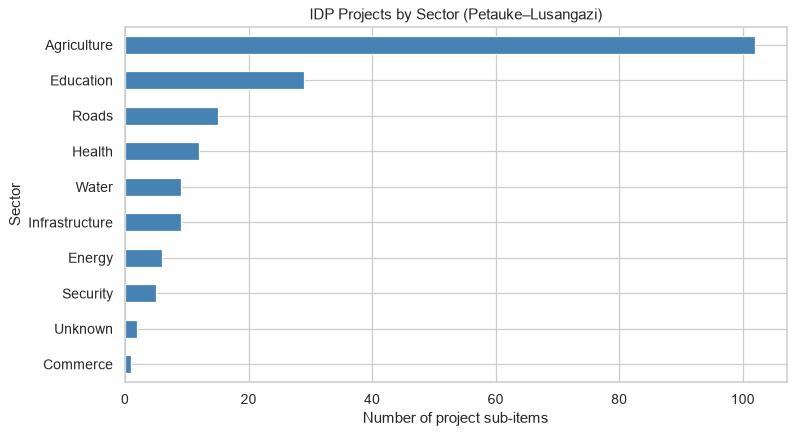


Insight: The largest sector is Agriculture with 102 records.


In [ ]:
proj = load("db-unza26-csc4792-petauke_lusangazi_idp_projects.csv")

sector_counts = proj["sector"].value_counts()

fig, ax = plt.subplots(figsize=(9, 5))
sector_counts.plot(kind="barh", ax=ax, color="steelblue")
ax.set_xlabel("Number of project sub-items")
ax.set_ylabel("Sector")
ax.set_title("IDP Projects by Sector (Petauke–Lusangazi)")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

print("\nInsight: The largest sector is",
      sector_counts.idxmax(), "with", sector_counts.max(), "records.")

### 12.2 Projects per chiefdom

Projects span five chiefdom sections. We compare activity across
chiefdom areas to see which chiefdoms received the most project
investment under the IDP.

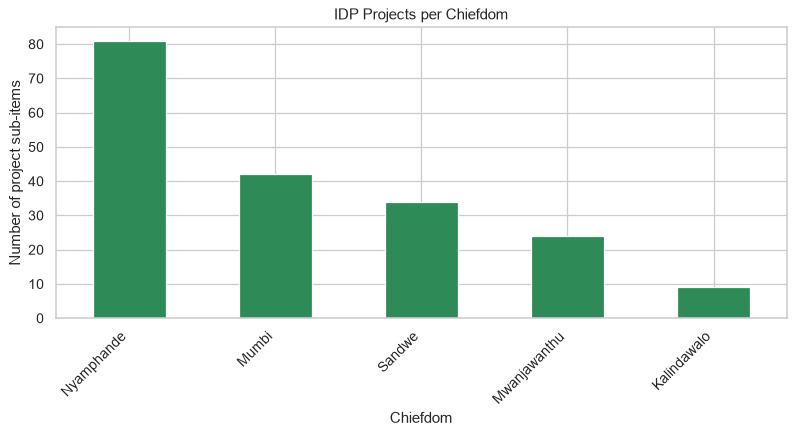


Insight: Chiefdom with most projects: Nyamphande ( 81 records )


In [ ]:
chief_counts = proj["chiefdom"].value_counts()

fig, ax = plt.subplots(figsize=(9, 5))
chief_counts.plot(kind="bar", ax=ax, color="seagreen")
ax.set_xlabel("Chiefdom")
ax.set_ylabel("Number of project sub-items")
ax.set_title("IDP Projects per Chiefdom")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

print("\nInsight: Chiefdom with most projects:", chief_counts.idxmax(),
      "(", chief_counts.max(), "records )")

### 12.3 Wards per constituency and district

The IDP ward list contains 20 wards. We break them down by constituency
and district.

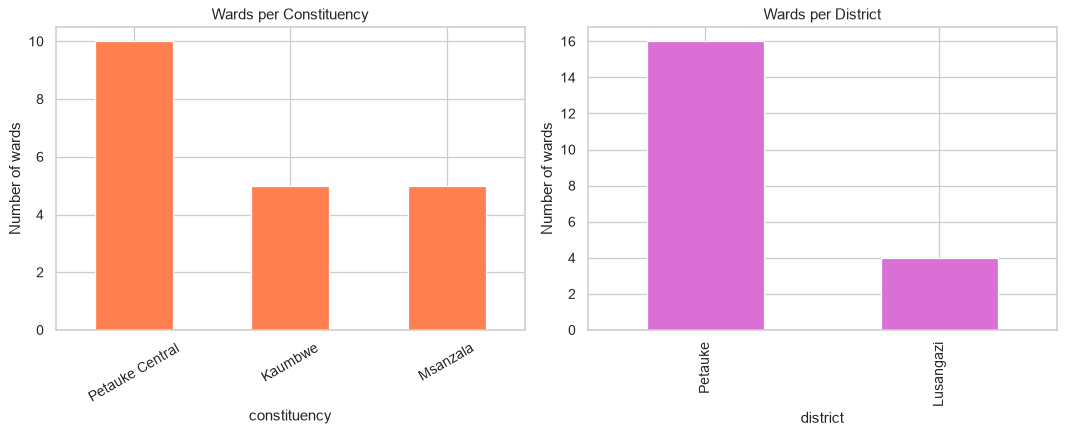

In [ ]:
wards = load("db-unza26-csc4792-petauke_lusangazi_idp_wards.csv")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

wards["constituency"].value_counts().plot(kind="bar", ax=axes[0], color="coral")
axes[0].set_title("Wards per Constituency")
axes[0].set_ylabel("Number of wards")
axes[0].tick_params(axis="x", rotation=30)

wards["district"].value_counts().plot(kind="bar", ax=axes[1], color="orchid")
axes[1].set_title("Wards per District")
axes[1].set_ylabel("Number of wards")

plt.tight_layout()
plt.show()

### 12.4 Provincial urban population trends

The Strategic Plan's population table gives urban population percentages
for each Zambian province over 2011, 2015, and 2020.

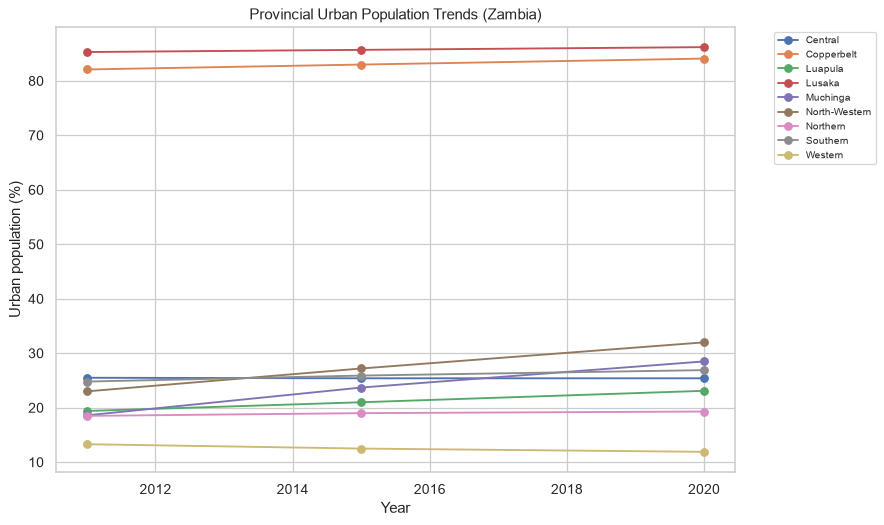

In [ ]:
pop = load("db-unza26-csc4792-petauke_stratplan_population.csv")
pop["year"]      = pd.to_numeric(pop["year"])
pop["urban_pct"] = pd.to_numeric(pop["urban_pct"])

# Exclude Zambia national total for a cleaner provincial view
prov_pop = pop[pop["province"] != "Zambia"]

fig, ax = plt.subplots(figsize=(10, 6))
for prov, group in prov_pop.groupby("province"):
    group = group.sort_values("year")
    ax.plot(group["year"], group["urban_pct"], marker="o", label=prov)

ax.set_xlabel("Year")
ax.set_ylabel("Urban population (%)")
ax.set_title("Provincial Urban Population Trends (Zambia)")
ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()

### 12.5 Employment by perspective

The employment table distinguishes International and Local perspectives
of the labour market.

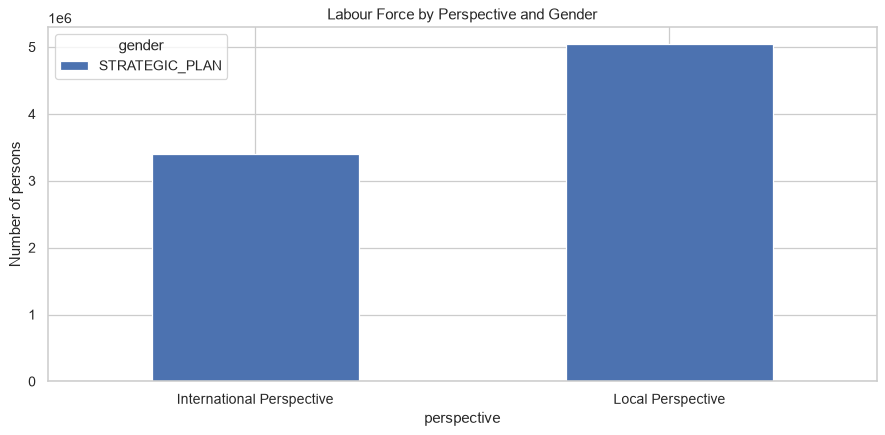

In [ ]:
emp = load("db-unza26-csc4792-petauke_stratplan_employment.csv")
for c in ["labour_force", "persons_in_employment", "persons_in_unemployment"]:
    emp[c] = pd.to_numeric(emp[c])

fig, ax = plt.subplots(figsize=(10, 5))
emp.pivot_table(
    index="perspective", columns="gender",
    values="labour_force", aggfunc="first"
).plot(kind="bar", ax=ax)

ax.set_title("Labour Force by Perspective and Gender")
ax.set_ylabel("Number of persons")
ax.tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.show()

### 12.6 Health cases by disease category

Health records are categorised by disease type. We compare total cases
across categories.

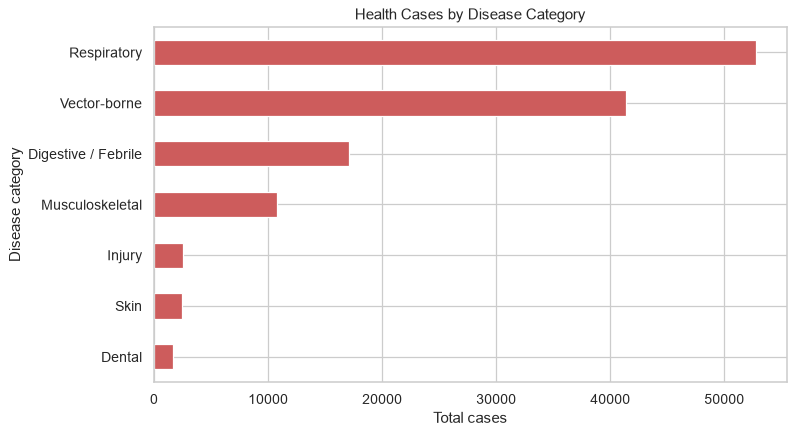

In [ ]:
health = load("db-unza26-csc4792-petauke_stratplan_health.csv")
health["cases"] = pd.to_numeric(health["cases"])

fig, ax = plt.subplots(figsize=(9, 5))
health.groupby("disease_category")["cases"].sum().sort_values().plot(
    kind="barh", ax=ax, color="indianred"
)
ax.set_xlabel("Total cases")
ax.set_ylabel("Disease category")
ax.set_title("Health Cases by Disease Category")
plt.tight_layout()
plt.show()

### 12.7 Summary — Key insights from EDA

Analysis of the 7 curated datasets produced the following findings:

**IDP Projects by Sector**
- Agriculture dominates with 102 project sub-items (54% of the total),
  reflecting the rural, agriculture-based economy of Petauke and
  Lusangazi districts.
- Education is the second-largest sector (29 records), followed by
  Roads (15).
- Water, Infrastructure, and Health each account for approximately
  9–12 records.
- Energy (6), Security (5), and Commerce (1) are minor categories,
  suggesting they were lower priorities in the IDP.

**IDP Projects per Chiefdom**
- All five chiefdoms (Kalindawalo, Mumbi, Mwanjawanthu, Nyamphande,
  Sandwe) are represented in the project implementation plan.
- Projects are not concentrated in a single chiefdom — development is
  spread across constituencies.

**IDP Wards**
- 20 wards were catalogued, distributed across three constituencies
  (Petauke Central, Kaumbwe, Msanzala) and two districts (Petauke,
  Lusangazi).
- Petauke district contains the majority of the wards.

**Population Trends**
- Urban populations across all Zambian provinces trend upward from
  2011 to 2020.
- Lusaka and Copperbelt consistently show the highest urbanisation
  (85%+), while Luapula, Western, and Northern remain below 25%.
- Petauke district (in Eastern Province) sits in a mixed-urbanisation
  region, consistent with its economic profile.

**Employment**
- Local perspective employment figures exceed International perspective
  figures by roughly 1.5× in labour force terms.
- Male labour force participation is consistently higher than female,
  across both perspectives.

**Health**
- Respiratory infections and Malaria together account for the majority
  of reported cases, reflecting common public health burdens in the
  region.
- Non-communicable and injury categories contribute much smaller
  proportions.

These insights demonstrate the dataset's value for:
- Local government planning and budget allocation.
- Comparative analysis across provinces and chiefdoms.
- Public health and education sector targeting.
- Reuse by researchers studying Zambian local governance.

# CDF Dataset Construction — Kaumbwe & Petauke Councils

This notebook documents the extraction, cleaning, and preprocessing of
Community/Constituency Development Fund (CDF) project data from three
raw CSV files:

1. `2025-PROPOSED-COMMUNITY-PROJECTS-KAUMBWE2.csv`
2. `2025-NOT-APPROVED-COMMUNITY-PROJECTS-KAUMBWE2.csv`
3. `2022-COMMUNITY-PROJECTS-PETAUKE-CENTRAL.csv`

The goal is to produce a single tidy CSV using the pipe `|` separator,
named `db-unza26-csc4792-cdf_projects.csv`.

In [13]:
from pathlib import Path
import pandas as pd
import numpy as np
import re

data_folder = Path("../data/raw")

csv_files = sorted(data_folder.glob("*.csv"))
pdf_files = sorted(data_folder.glob("*.pdf"))

print("CSV files:")
for f in csv_files:
    print(" -", f.name)

print("\nPDF files:")
for f in pdf_files:
    print(" -", f.name)

CSV files:
 - 2022-COMMUNITY-PROJECTS-PETAUKE-CENTRAL.csv
 - 2025-NOT-APPROVED-COMMUNITY-PROJECTS-KAUMBWE2.csv
 - 2025-PROPOSED-COMMUNITY-PROJECTS-KAUMBWE2.csv

PDF files:
 - 11th-July-2025-Council-Minutes.pdf
 - 30th-April-2025- Council-Minutes.pdf
 - Petauke-Town-Council-2025-OBB-Final-05.12.2024_Signed.pdf
 - Petauke-Town-Council-2026-Budget-2026.pdf
 - Petauke-Town-Council-Stratplan_2019-23.pdf
 - Petauke.Lusangazi-Joint-IDP-Final.pdf


In [14]:
file_map = {
    "kaumbwe_proposed":  "2025-PROPOSED-COMMUNITY-PROJECTS-KAUMBWE2.csv",
    "kaumbwe_rejected":  "2025-NOT-APPROVED-COMMUNITY-PROJECTS-KAUMBWE2.csv",
    "petauke_approved":  "2022-COMMUNITY-PROJECTS-PETAUKE-CENTRAL.csv",
}

raw = {}
for key, fname in file_map.items():
    path = data_folder / fname
    df = pd.read_csv(path, encoding="utf-8-sig", dtype=str)
    raw[key] = df
    print(f"\n=== {key} === shape: {df.shape}")
    print("Columns:", list(df.columns))
    display(df.head(3))


=== kaumbwe_proposed === shape: (106, 9)
Columns: ['No.', 'Project Name', 'Project Description', 'Sector', 'Type of Project', 'Constituency', 'Ward', 'Project Site/Location', 'Project Amount Requested']


,No.,Project Name,Project Description,Sector,Type of Project,Constituency,Ward,Project Site/Location,Project Amount Requested
0,1,Classroom Block,1x2 Classroom Block,Education,Construction of 1x2 Classroom Block,Kaumbwe,Kanyanga,Kanyanga B School,"70,000"
1,2,Health Post,Health Post,Health,Construction and Rehabilitation of a Health Post,Kaumbwe,Kanyanga,Nyakutwa Health Post,"700,000"
2,3,Staff Houses,3 Staff Houses,Health,Construction of 3 Staff House,Kaumbwe,Kanyanga,Matonje Health Post,"820,000"



=== kaumbwe_rejected === shape: (93, 10)
Columns: ['No.', 'Project Name', 'Project Description', 'Sector', 'Type of Project', 'Constituency', 'Ward', 'Project Site/Location', 'Project Amount Requested', 'COMMENTS']


,No.,Project Name,Project Description,Sector,Type of Project,Constituency,Ward,Project Site/Location,Project Amount Requested,COMMENTS
0,1,Classroom Block,1x2 Classroom Block,Education,Construction of 1x2 Classroom Block,Kaumbwe,Kanyanga,Kanyanga B School,"70,000",Funds were not adequate for all projects to be...
1,2,Health Post,Health Post,Health,Construction and Rehabilitation of a Health Post,Kaumbwe,Kanyanga,Nyakutwa Health Post,"700,000",Funds were not adequate for all projects to be...
2,3,Staff Houses,3 Staff Houses,Health,Construction of 3 Staff House,Kaumbwe,Kanyanga,Matonje Health Post,"820,000",Funds were not adequate for all projects to be...



=== petauke_approved === shape: (20, 12)
Columns: ['No.', 'Project Name', 'Project Description', 'Sector', 'Type of Project', 'Province', 'District', 'Constituency', 'Ward', 'Project Site/Location', 'Approved Amount', 'Year Funded']


,No.,Project Name,Project Description,Sector,Type of Project,Province,District,Constituency,Ward,Project Site/Location,Approved Amount,Year Funded
0,1,CLASSROOM CONSTRUCTION,CONSTRUCTION OF 1X2 CLASSROOM BLOCK,Education,CONSTRUCTION,EASTERN,PETAUKE,PETAUKE CENTRAL,CHILIMANYAMA,Cheuka,"500,000",2022
1,2,HEALTH POST CONSTRUCTION,Construction of 1 Health post,HEALTH,CONSTRUCTION,EASTERN,PETAUKE,PETAUKE CENTRAL,CHILIMANYAMA,Lukasi,"400,000",2022
2,3,CLASSROOM CONSTRUCTION,CONSTRUCTION OF 1X2 CLASSROOM BLOCK,Education,CONSTRUCTION,EASTERN,PETAUKE,PETAUKE CENTRAL,KOVYANE,Kamwankhuku,"500,000",2022


## 2. Standardise column names

Renaming each file to a common schema:
`project_id, project_name, project_description, sector, project_type,
province, district, constituency, ward, project_site,
amount_requested_zmw, approved_amount_zmw, year_funded, comments, status, source_file`

Missing fields are added as `NaN` so the frames can be concatenated.

In [15]:
CANONICAL_COLS = [
    "project_id", "project_name", "project_description",
    "sector", "project_type",
    "province", "district", "constituency", "ward", "project_site",
    "amount_requested_zmw", "approved_amount_zmw", "year_funded",
    "comments", "status", "source_file",
]

rename_map = {
    "No.": "project_id",
    "Project Name": "project_name",
    "Project Description": "project_description",
    "Sector": "sector",
    "Type of Project": "project_type",
    "Province": "province",
    "District": "district",
    "Constituency": "constituency",
    "Ward": "ward",
    "Project Site/Location": "project_site",
    "Project Amount Requested": "amount_requested_zmw",
    "Approved Amount": "approved_amount_zmw",
    "Year Funded": "year_funded",
    "COMMENTS": "comments",
}

def clean_cols(df):
    df.columns = [c.replace("\ufeff", "").strip() for c in df.columns]
    return df

frames = []
for key, fname in file_map.items():
    df = clean_cols(raw[key].copy()).rename(columns=rename_map)

    # add source & status
    df["source_file"] = fname
    if key == "kaumbwe_proposed":
        df["status"] = "Proposed"
    elif key == "kaumbwe_rejected":
        df["status"] = "Not Approved"
    else:
        df["status"] = "Approved"

    # add any missing canonical columns as NaN
    for col in CANONICAL_COLS:
        if col not in df.columns:
            df[col] = np.nan

    df = df[CANONICAL_COLS]
    frames.append(df)

df_all = pd.concat(frames, ignore_index=True)
print("Combined shape:", df_all.shape)
df_all.head()

Combined shape: (219, 16)


,project_id,project_name,project_description,sector,project_type,province,district,constituency,ward,project_site,amount_requested_zmw,approved_amount_zmw,year_funded,comments,status,source_file
0,1,Classroom Block,1x2 Classroom Block,Education,Construction of 1x2 Classroom Block,NaN,NaN,Kaumbwe,Kanyanga,Kanyanga B School,"70,000",NaN,NaN,NaN,Proposed,2025-PROPOSED-COMMUNITY-PROJECTS-KAUMBWE2.csv
1,2,Health Post,Health Post,Health,Construction and Rehabilitation of a Health Post,NaN,NaN,Kaumbwe,Kanyanga,Nyakutwa Health Post,"700,000",NaN,NaN,NaN,Proposed,2025-PROPOSED-COMMUNITY-PROJECTS-KAUMBWE2.csv
2,3,Staff Houses,3 Staff Houses,Health,Construction of 3 Staff House,NaN,NaN,Kaumbwe,Kanyanga,Matonje Health Post,"820,000",NaN,NaN,NaN,Proposed,2025-PROPOSED-COMMUNITY-PROJECTS-KAUMBWE2.csv
3,4,Bull Dozer,Bull Dozer,Roads,Purchase of a Bull Dozer,NaN,NaN,Kaumbwe,Kanyanga,Kanyanga,"2,400,550,000",NaN,NaN,NaN,Proposed,2025-PROPOSED-COMMUNITY-PROJECTS-KAUMBWE2.csv
4,5,Grader,Grader,Roads,Purchase of a Grader,NaN,NaN,Kaumbwe,Kanyanga,Kanyanga,"2,110,250,000",NaN,NaN,NaN,Proposed,2025-PROPOSED-COMMUNITY-PROJECTS-KAUMBWE2.csv


## 3. Clean `project_id`

Each source file restarts numbering at 1, so IDs do not collide across files.
This done by a globally unique ID by prefixing with the source key.

In [16]:
prefix_map = {
    "2025-PROPOSED-COMMUNITY-PROJECTS-KAUMBWE2.csv": "KPR",   # Kaumbwe Proposed(KPR)
    "2025-NOT-APPROVED-COMMUNITY-PROJECTS-KAUMBWE2.csv": "KNA", # Kaumbwe Not Approved(KNA)
    "2022-COMMUNITY-PROJECTS-PETAUKE-CENTRAL.csv": "PCA",      # Petauke Central Approved(PCA)
}

df_all["project_id"] = (
    df_all["source_file"].map(prefix_map) + "-" + df_all["project_id"].astype(str)
)
df_all[["project_id", "source_file"]].head()

,project_id,source_file
0,KPR-1,2025-PROPOSED-COMMUNITY-PROJECTS-KAUMBWE2.csv
1,KPR-2,2025-PROPOSED-COMMUNITY-PROJECTS-KAUMBWE2.csv
2,KPR-3,2025-PROPOSED-COMMUNITY-PROJECTS-KAUMBWE2.csv
3,KPR-4,2025-PROPOSED-COMMUNITY-PROJECTS-KAUMBWE2.csv
4,KPR-5,2025-PROPOSED-COMMUNITY-PROJECTS-KAUMBWE2.csv


## 4. Clean text fields

- Strip surrounding whitespace
- Collapse multiple spaces
- Fix common typos (`Acess` → `Access`, `Domitary` → `Dormitory`,
  `Dinning` → `Dining`)
- Replace Cyrillic lookalikes (e.g. `а` in `Ndelemyа`)

In [17]:
TEXT_COLS = [
    "project_name", "project_description", "sector", "project_type",
    "province", "district", "constituency", "ward", "project_site",
    "comments",
]

CYRILLIC_MAP = str.maketrans({"а": "a", "е": "e", "о": "o",
                              "р": "p", "с": "c", "у": "y", "х": "x"})

TYPOS = {
    r"\bAcess\b": "Access",
    r"\bDomitary\b": "Dormitory",
    r"\bDinning\b": "Dining",
    r"\bC;assroom\b": "Classroom",
}

def clean_text(s):
    if pd.isna(s):
        return s
    s = str(s).translate(CYRILLIC_MAP)
    s = re.sub(r"\s+", " ", s).strip()
    for pat, rep in TYPOS.items():
        s = re.sub(pat, rep, s, flags=re.IGNORECASE)
    return s

for col in TEXT_COLS:
    df_all[col] = df_all[col].apply(clean_text)

# check the Cyrillic fix
df_all[df_all["project_site"].str.contains("Ndelemy", na=False)][["project_site"]]

,project_site
202,Ndelemya


## 5. Standardise categorical values

Sector is inconsistent across files (`EDUCATION`, `Education`, `HEALTH`,
`Health`). We normalise to Title Case and merge obvious synonyms.

In [18]:
SECTOR_MAP = {
    "education": "Education",
    "health": "Health",
    "water and sanitation": "Water and Sanitation",
    "home affairs": "Home Affairs",
    "fisheries and livestock": "Fisheries and Livestock",
    "judiciary": "Judiciary",
    "communication": "Communication",
    "roads": "Roads",
}

def standardise_sector(s):
    if pd.isna(s):
        return np.nan
    return SECTOR_MAP.get(str(s).strip().lower(), str(s).strip().title())

df_all["sector"] = df_all["sector"].apply(standardise_sector)

# Province / District — fill from known context
df_all.loc[df_all["source_file"].str.contains("KAUMBWE"), "province"] = "Muchinga"
df_all.loc[df_all["source_file"].str.contains("KAUMBWE"), "district"]   = "Kaumbwe"
df_all.loc[df_all["source_file"].str.contains("PETAUKE"), "province"]   = "Eastern"
df_all.loc[df_all["source_file"].str.contains("PETAUKE"), "district"]   = "Petauke"

# Title-case geographic fields
for col in ["province", "district", "constituency", "ward"]:
    df_all[col] = df_all[col].str.title()

df_all[["sector", "province", "district", "ward"]].drop_duplicates().head(20)

,sector,province,district,ward
0,Education,Muchinga,Kaumbwe,Kanyanga
1,Health,Muchinga,Kaumbwe,Kanyanga
3,Roads,Muchinga,Kaumbwe,Kanyanga
5,Water and Sanitation,Muchinga,Kaumbwe,Kanyanga
17,Home Affairs,Muchinga,Kaumbwe,Kanyanga
18,Agriculture,Muchinga,Kaumbwe,Kanyanga
25,Education,Muchinga,Kaumbwe,Manyane
26,Water and Sanitation,Muchinga,Kaumbwe,Manyane
27,Health,Muchinga,Kaumbwe,Manyane
37,Education,Muchinga,Kaumbwe,Kaumbwe


Fix the sector misclassification flagged earlier (Petauke row 6):



In [19]:
mask = (
    df_all["project_description"].str.contains("CLASSROOM", case=False, na=False)
    & (df_all["sector"] == "Health")
)
print("Misclassified rows:", mask.sum())
df_all.loc[mask, "sector"] = "Education"

Misclassified rows: 1


## 6. Clean amount columns

Rules:
- Remove thousands separators (`,`)
- Treat `NIL`, empty string, and whitespace as missing (`NaN`)
- Convert to numeric (`float`), preserving decimals (e.g. `1,198,607.25`)

In [20]:
def parse_amount(x):
    if pd.isna(x):
        return np.nan
    s = str(x).strip().replace(",", "")
    if s.upper() in {"NIL", "", "N/A", "NA", "-"}:
        return np.nan
    try:
        return float(s)
    except ValueError:
        return np.nan

for col in ["amount_requested_zmw", "approved_amount_zmw"]:
    df_all[col] = df_all[col].apply(parse_amount)

df_all[["amount_requested_zmw", "approved_amount_zmw"]].describe()

,amount_requested_zmw,approved_amount_zmw
count,1.760000e+02,20.000000
mean,2.616738e+07,461870.600000
std,2.401839e+08,48579.958428
min,3.000000e+03,400000.000000
25%,6.000000e+04,400000.000000
50%,3.180000e+05,500000.000000
75%,7.050000e+05,500000.000000
max,2.400550e+09,500000.000000


## 7. Clean `year_funded`

Only the Petauke file has a year; the Kaumbwe files have the year in the
filename (2025). These are backfill accordingly.

In [21]:
df_all["year_funded"] = pd.to_numeric(df_all["year_funded"], errors="coerce")

# Backfilling Kaumbwe rows from filename year
kaumbwe_mask = df_all["source_file"].str.contains("KAUMBWE")
df_all.loc[kaumbwe_mask, "year_funded"] = 2025

df_all["year_funded"] = df_all["year_funded"].astype("Int64")
df_all["year_funded"].value_counts(dropna=False)

year_funded
2025    199
2022     20
Name: count, dtype: Int64

## 8. Derived attributes

The dataset enrich  with:
- `has_amount` — 1 if any amount is present
- `amount_category` — binned on the effective amount
- `funding_year` — same as `year_funded` but labelled

In [22]:
df_all["effective_amount_zmw"] = df_all["approved_amount_zmw"].fillna(
    df_all["amount_requested_zmw"]
)
df_all["has_amount"] = df_all["effective_amount_zmw"].notna().astype(int)

def categorise(a):
    if pd.isna(a):
        return "Unknown"
    if a < 100_000:
        return "Low (<100K)"
    if a < 1_000_000:
        return "Medium (100K–1M)"
    return "High (>1M)"

df_all["amount_category"] = df_all["effective_amount_zmw"].apply(categorise)

df_all[["effective_amount_zmw", "amount_category", "has_amount"]].head()

,effective_amount_zmw,amount_category,has_amount
0,7.000000e+04,Low (<100K),1
1,7.000000e+05,Medium (100K–1M),1
2,8.200000e+05,Medium (100K–1M),1
3,2.400550e+09,High (>1M),1
4,2.110250e+09,High (>1M),1


## 9. Missing value audit


In [23]:
missing = df_all.isna().sum().sort_values(ascending=False)
missing_pct = (missing / len(df_all) * 100).round(2)
report = pd.DataFrame({"missing": missing, "pct": missing_pct})
report

,missing,pct
approved_amount_zmw,199,90.87
comments,126,57.53
amount_requested_zmw,43,19.63
effective_amount_zmw,23,10.50
project_site,10,4.57
sector,4,1.83
project_id,0,0.00
project_description,0,0.00
project_name,0,0.00
district,0,0.00


## 10. Final schema and export

Droping helper columns, ordering the schema, and exporting using the pipe `|`.

Output: `db-unza26-csc4792-cdf_projects.csv`

In [24]:
FINAL_COLS = [
    "project_id", "project_name", "project_description",
    "sector", "project_type",
    "province", "district", "constituency", "ward", "project_site",
    "amount_requested_zmw", "approved_amount_zmw", "effective_amount_zmw",
    "amount_category", "has_amount",
    "year_funded", "status", "comments", "source_file",
]

df_final = df_all[FINAL_COLS].copy()

out_dir = Path("../data/transformed")
out_dir.mkdir(parents=True, exist_ok=True)
out_path = out_dir / "db-unza26-csc4792-cdf_projects_2022_&_2025.csv"

df_final.to_csv(out_path, sep="|", index=False, encoding="utf-8")
print("Written:", out_path, "| rows:", len(df_final), "| cols:", df_final.shape[1])

Written: ../data/transformed/db-unza26-csc4792-cdf_projects_2022_&_2025.csv | rows: 219 | cols: 19
